# Physics constrained NN

In [1]:
import gdown
import os
import time
import h5py
import numpy as np
from scipy.signal import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Download dataset
DATA_URL = "https://drive.google.com/uc?export=download&id=1Q2Qo_1VGlCsVOTjQpZlE5tjoIV1etVe2"
DATA_PATH = "data_file.h5"

if not os.path.exists(DATA_PATH):
    gdown.download(DATA_URL, DATA_PATH, quiet=False)
else:
    print(f"Dataset already exists at {DATA_PATH}")

# Helpers
class GlobalStandardScaler:
    def __init__(self):
        self.mean = 0.0
        self.std = 1.0

    def fit(self, x):
        self.mean = float(np.mean(x))
        self.std = float(np.std(x))
        if self.std == 0:
            self.std = 1.0

    def transform(self, x):
        return (x - self.mean) / self.std

    def fit_transform(self, x):
        self.fit(x)
        return self.transform(x)

    def inverse_transform(self, x):
        return x * self.std + self.mean


def convert_fit_dataset_to_numeric(fit_ds_np):
    """
    Converts HDF5 SHO fit dataset into numeric array of shape [num_pix, voltage_steps, num_params].
    Handles:
      - structured/compound dtype datasets
      - already numeric 3D arrays
      - object arrays / nested arrays
    """
    print("Raw Fit dataset shape:", fit_ds_np.shape)
    print("Raw Fit dataset dtype:", fit_ds_np.dtype)

    # Case 1: structured / compound dtype
    if fit_ds_np.dtype.names is not None:
        field_names = fit_ds_np.dtype.names
        print("Detected structured dtype fields:", field_names)
        fit_results = np.stack([fit_ds_np[name] for name in field_names], axis=-1)
        return np.asarray(fit_results, dtype=np.float64)

    # Case 2: already numeric with final param axis
    if np.issubdtype(fit_ds_np.dtype, np.number):
        if fit_ds_np.ndim == 3:
            return np.asarray(fit_ds_np, dtype=np.float64)
        elif fit_ds_np.ndim == 2:
            raise ValueError(
                f"Fit dataset is 2D numeric with shape {fit_ds_np.shape}; expected structured dtype or 3D numeric."
            )

    # Case 3: fallback for nested/object arrays
    flat_rows = []
    for row in fit_ds_np:
        for item in row:
            flat_rows.append(np.array(item, dtype=np.float64).ravel())

    fit_results = np.array(flat_rows, dtype=np.float64)
    return fit_results


def sho_fit_func_torch(params, wvec_freq, device=None):
    """
    params: [batch, 4] = [Amp, w0, Q, phi]
    returns complex SHO response [batch, num_freq]
    """
    if device is None:
        device = params.device

    wvec_freq = torch.as_tensor(wvec_freq, dtype=torch.float64, device=device)

    Amp = params[:, 0].to(torch.float64).unsqueeze(1)
    w0  = params[:, 1].to(torch.float64).unsqueeze(1)
    Q   = params[:, 2].to(torch.float64).unsqueeze(1)
    phi = params[:, 3].to(torch.float64).unsqueeze(1)

    Amp = Amp.to(torch.complex128)
    w0  = w0.to(torch.complex128)
    Q   = Q.to(torch.complex128)
    phi = phi.to(torch.complex128)
    w   = wvec_freq.to(torch.complex128).unsqueeze(0)

    numer = Amp * torch.exp(1j * phi) * (w0 ** 2)
    denom = (w ** 2) - (1j * w * w0 / Q) - (w0 ** 2)
    return numer / denom


# Load and preprocess data
with h5py.File(DATA_PATH, "r") as h5_f:
    meas = h5_f["Measurement_000"]
    chan = meas["Channel_000"]

    num_bins = int(meas.attrs["num_bins"])
    num_pix = int(meas.attrs["num_pix"])
    voltage_steps = int(meas.attrs["num_udvs_steps"])

    frequency_bin = chan["Bin_Frequencies"][:]
    wvec_freq = resample(frequency_bin, 80)

    raw_data = chan["Raw_Data"][:]  # complex array
    print("raw_data shape:", raw_data.shape)

    # Real / imag, reshape to [num_pix, voltage_steps, num_bins]
    real = np.real(raw_data).reshape(num_pix, voltage_steps, num_bins)
    imag = np.imag(raw_data).reshape(num_pix, voltage_steps, num_bins)

    # Resample freq axis: num_bins -> 80
    real_resample = resample(real, 80, axis=2)
    imag_resample = resample(imag, 80, axis=2)

    # Ground-truth fit parameters from existing LSQ/SHO fit
    fit_ds_np = np.array(chan["Raw_Data-SHO_Fit_000"]["Fit"])
    fit_results = convert_fit_dataset_to_numeric(fit_ds_np)

# Normalize fit_results to shape [num_pix, voltage_steps, num_params]
if fit_results.ndim == 2:
    # likely flattened [num_pix * voltage_steps, num_params]
    fit_results = fit_results.reshape(num_pix, voltage_steps, -1)
elif fit_results.ndim == 3:
    pass
else:
    raise ValueError(f"Unexpected fit_results shape after conversion: {fit_results.shape}")

print("fit_results final shape:", fit_results.shape)

# Flatten samples: [num_pix * voltage_steps, 80]
real_flat = real_resample.reshape(-1, 80)
imag_flat = imag_resample.reshape(-1, 80)

# Scale real/imag globally
scaler_real = GlobalStandardScaler()
scaler_imag = GlobalStandardScaler()
real_scaled = scaler_real.fit_transform(real_flat)
imag_scaled = scaler_imag.fit_transform(imag_flat)

# Stack as [N, 80, 2]
X = np.stack([real_scaled, imag_scaled], axis=2).astype(np.float32)

# Physical parameters [Amp, w0, Q, phi] only
params = fit_results.reshape(-1, fit_results.shape[-1])[:, :4].astype(np.float64)

params_scaler = StandardScaler()
params_scaled = params_scaler.fit_transform(params).astype(np.float32)

print("Input X shape:", X.shape)
print("Parameter shape:", params.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, params_scaled, test_size=0.7, random_state=SEED
)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=200,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=4096,
    shuffle=False
)

# AdaHessian optimizer
class AdaHessian(torch.optim.Optimizer):
    def __init__(
        self, params, lr=0.1, betas=(0.9, 0.999), eps=1e-8,
        weight_decay=0.0, hessian_power=1.0, update_each=1,
        n_samples=1, average_conv_kernel=False
    ):
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= eps:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta1: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta2: {betas[1]}")
        if not 0.0 <= hessian_power <= 1.0:
            raise ValueError(f"Invalid hessian_power: {hessian_power}")

        self.n_samples = n_samples
        self.update_each = update_each
        self.average_conv_kernel = average_conv_kernel
        self.generator = torch.Generator().manual_seed(2147483647)

        defaults = dict(
            lr=lr, betas=betas, eps=eps,
            weight_decay=weight_decay, hessian_power=hessian_power
        )
        super().__init__(params, defaults)

        for p in self.get_params():
            p.hess = 0.0
            self.state[p]["hessian_step"] = 0

    def get_params(self):
        return (p for group in self.param_groups for p in group["params"] if p.requires_grad)

    def zero_hessian(self):
        for p in self.get_params():
            if not isinstance(p.hess, float) and self.state[p]["hessian_step"] % self.update_each == 0:
                p.hess.zero_()

    @torch.no_grad()
    def set_hessian(self):
        params = []
        for p in filter(lambda p: p.grad is not None, self.get_params()):
            if self.state[p]["hessian_step"] % self.update_each == 0:
                params.append(p)
            self.state[p]["hessian_step"] += 1

        if len(params) == 0:
            return

        if self.generator.device != params[0].device:
            self.generator = torch.Generator(params[0].device).manual_seed(2147483647)

        grads = [p.grad for p in params]

        for i in range(self.n_samples):
            zs = [
                torch.randint(0, 2, p.size(), generator=self.generator, device=p.device) * 2.0 - 1.0
                for p in params
            ]
            h_zs = torch.autograd.grad(
                grads, params, grad_outputs=zs, only_inputs=True,
                retain_graph=i < self.n_samples - 1
            )
            for h_z, z, p in zip(h_zs, zs, params):
                p.hess += h_z * z / self.n_samples

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        self.zero_hessian()
        self.set_hessian()

        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None or p.hess is None:
                    continue

                if self.average_conv_kernel and p.dim() == 4:
                    p.hess = torch.abs(p.hess).mean(dim=[2, 3], keepdim=True).expand_as(p.hess).clone()

                p.mul_(1 - group["lr"] * group["weight_decay"])

                state = self.state[p]
                if len(state) == 1:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p.data)
                    state["exp_hessian_diag_sq"] = torch.zeros_like(p.data)

                exp_avg = state["exp_avg"]
                exp_hessian_diag_sq = state["exp_hessian_diag_sq"]
                beta1, beta2 = group["betas"]
                state["step"] += 1

                exp_avg.mul_(beta1).add_(p.grad, alpha=1 - beta1)
                exp_hessian_diag_sq.mul_(beta2).addcmul_(p.hess, p.hess, value=1 - beta2)

                bias_correction1 = 1 - beta1 ** state["step"]
                bias_correction2 = 1 - beta2 ** state["step"]

                k = group["hessian_power"]
                denom = (exp_hessian_diag_sq / bias_correction2).pow_(k / 2).add_(group["eps"])
                step_size = group["lr"] / bias_correction1

                p.addcdiv_(exp_avg, denom, value=-step_size)

        return loss


# Model
class SHOModel(nn.Module):
    def __init__(self, params_scaler, scaler_real, scaler_imag, wvec_freq):
        super().__init__()

        self.hidden_x1 = nn.Sequential(
            nn.Conv1d(2, 8, kernel_size=7),
            nn.SELU(),
            nn.Conv1d(8, 6, kernel_size=7),
            nn.SELU(),
            nn.Conv1d(6, 4, kernel_size=5),
            nn.SELU(),
        )

        self.hidden_xfc = nn.Sequential(
            nn.Linear(256, 20),
            nn.SELU(),
            nn.Linear(20, 20),
            nn.SELU(),
        )

        self.hidden_x2 = nn.Sequential(
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(2, 4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(4, 4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(4, 4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(4, 4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(4, 4, kernel_size=5),
            nn.SELU(),
            nn.Conv1d(4, 4, kernel_size=5),
            nn.SELU(),
            nn.AvgPool1d(kernel_size=2),
            nn.Conv1d(4, 2, kernel_size=3),
            nn.SELU(),
            nn.AvgPool1d(kernel_size=2),
            nn.Conv1d(2, 2, kernel_size=3),
            nn.SELU(),
            nn.AvgPool1d(kernel_size=2),
        )

        self.flatten = nn.Flatten()

        self.hidden_embedding = nn.Sequential(
            nn.Linear(26, 16),
            nn.SELU(),
            nn.Linear(16, 8),
            nn.SELU(),
            nn.Linear(8, 4),
        )

        # register non-trainable buffers so they move with the model
        self.register_buffer("param_mean", torch.tensor(params_scaler.mean_, dtype=torch.float64))
        self.register_buffer("param_std", torch.tensor(np.sqrt(params_scaler.var_), dtype=torch.float64))
        self.register_buffer("real_mean", torch.tensor(scaler_real.mean, dtype=torch.float64))
        self.register_buffer("real_std", torch.tensor(scaler_real.std, dtype=torch.float64))
        self.register_buffer("imag_mean", torch.tensor(scaler_imag.mean, dtype=torch.float64))
        self.register_buffer("imag_std", torch.tensor(scaler_imag.std, dtype=torch.float64))
        self.register_buffer("wvec_freq_t", torch.tensor(wvec_freq, dtype=torch.float64))

    def encode_params(self, x):
        n = x.shape[0]
        x = torch.swapaxes(x, 1, 2)  # [batch, 2, 80]

        x1 = self.hidden_x1(x)  # [batch, 4, 64]
        xfc = x1.reshape(n, 256)
        xfc = self.hidden_xfc(xfc)

        x2 = x1.reshape(n, 2, 128)
        x2 = self.hidden_x2(x2)
        cnn_flat = self.flatten(x2)

        encoded = torch.cat((cnn_flat, xfc), dim=1)
        params_scaled_pred = self.hidden_embedding(encoded)  # [batch, 4]

        params_unscaled = (
            params_scaled_pred.to(torch.float64) * self.param_std.unsqueeze(0)
            + self.param_mean.unsqueeze(0)
        )
        return params_unscaled

    def forward(self, x):
        params_unscaled = self.encode_params(x)
        fits = sho_fit_func_torch(params_unscaled, self.wvec_freq_t, device=x.device)

        real = torch.real(fits)
        imag = torch.imag(fits)

        real_scaled = (real - self.real_mean) / self.real_std
        imag_scaled = (imag - self.imag_mean) / self.imag_std

        out = torch.stack((real_scaled, imag_scaled), dim=2).to(torch.float32)
        return out


model = SHOModel(params_scaler, scaler_real, scaler_imag, wvec_freq).to(device)
print(model)

# Training
loss_fn = nn.MSELoss()
optimizer = AdaHessian(model.parameters(), lr=0.1)
epochs = 5

for epoch in range(epochs):
    start = time.time()
    model.train()
    running_loss = 0.0
    total = 0

    for xb, _ in train_loader:
        xb = xb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred.double(), xb.double())
        loss.backward(create_graph=True)
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    epoch_loss = running_loss / total
    print(f"Epoch {epoch+1}/{epochs} | recon loss = {epoch_loss:.8f} | time = {time.time()-start:.2f}s")

torch.save(model.state_dict(), "model_AdaHessian_clean.pth")
print("Saved model to model_AdaHessian_clean.pth")

# Evaluation: reconstruction
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb)
        all_preds.append(pred.cpu())
        all_true.append(xb.cpu())

predictions = torch.cat(all_preds, dim=0).numpy()
X_test_np = torch.cat(all_true, dim=0).numpy()

mse_real = mean_squared_error(X_test_np[:, :, 0], predictions[:, :, 0])
mse_imag = mean_squared_error(X_test_np[:, :, 1], predictions[:, :, 1])
avg_mse = 0.5 * (mse_real + mse_imag)

print(f"MSE real: {mse_real:.8e}")
print(f"MSE imag: {mse_imag:.8e}")
print(f"Avg  MSE: {avg_mse:.8e}")

# Unscale reconstructions back to complex spectra
X_test_unscaled = np.empty_like(X_test_np, dtype=np.float64)
pred_unscaled = np.empty_like(predictions, dtype=np.float64)

X_test_unscaled[:, :, 0] = scaler_real.inverse_transform(X_test_np[:, :, 0])
X_test_unscaled[:, :, 1] = scaler_imag.inverse_transform(X_test_np[:, :, 1])

pred_unscaled[:, :, 0] = scaler_real.inverse_transform(predictions[:, :, 0])
pred_unscaled[:, :, 1] = scaler_imag.inverse_transform(predictions[:, :, 1])

X_test_complex = X_test_unscaled[:, :, 0] + 1j * X_test_unscaled[:, :, 1]
pred_complex = pred_unscaled[:, :, 0] + 1j * pred_unscaled[:, :, 1]

# Per-sample reconstruction error
errors = np.mean((X_test_np - predictions) ** 2, axis=(1, 2))
worst_idx = np.argsort(-errors)[:5]
best_idx = np.argsort(errors)[:5]

print("Best sample indices:", best_idx)
print("Worst sample indices:", worst_idx)

# Parameter prediction
pred_params = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        params_pred = model.encode_params(xb)
        pred_params.append(params_pred.cpu())

pred_params = torch.cat(pred_params, dim=0).numpy()  # unscaled physical params
true_params = params_scaler.inverse_transform(y_test)

param_mse = ((pred_params - true_params) ** 2).mean(axis=0)
print("Parameter MSE [Amp, w0, Q, phi]:", param_mse)

print("\nDone.")

Using device: cpu
Dataset already exists at data_file.h5
raw_data shape: (3600, 63360)
Raw Fit dataset shape: (3600, 384)
Raw Fit dataset dtype: [('Amplitude [V]', '<f4'), ('Frequency [Hz]', '<f4'), ('Quality Factor', '<f4'), ('Phase [rad]', '<f4'), ('R2 Criterion', '<f4')]
Detected structured dtype fields: ('Amplitude [V]', 'Frequency [Hz]', 'Quality Factor', 'Phase [rad]', 'R2 Criterion')
fit_results final shape: (3600, 384, 5)
Input X shape: (1382400, 80, 2)
Parameter shape: (1382400, 4)
SHOModel(
  (hidden_x1): Sequential(
    (0): Conv1d(2, 8, kernel_size=(7,), stride=(1,))
    (1): SELU()
    (2): Conv1d(8, 6, kernel_size=(7,), stride=(1,))
    (3): SELU()
    (4): Conv1d(6, 4, kernel_size=(5,), stride=(1,))
    (5): SELU()
  )
  (hidden_xfc): Sequential(
    (0): Linear(in_features=256, out_features=20, bias=True)
    (1): SELU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): SELU()
  )
  (hidden_x2): Sequential(
    (0): MaxPool1d(kernel_size=2, stride=2, 

/ml/conda_envs/rforelli/envs/sho-project/lib/python3.11/site-packages/torch/autograd/graph.py:865: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /pytorch/torch/csrc/autograd/engine.cpp:1301.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/5 | recon loss = 0.09924092 | time = 102.64s
Epoch 2/5 | recon loss = 0.05113524 | time = 100.26s
Epoch 3/5 | recon loss = 0.04781414 | time = 99.54s
Epoch 4/5 | recon loss = 0.04677921 | time = 97.18s
Epoch 5/5 | recon loss = 0.04621229 | time = 99.18s
Saved model to model_AdaHessian_clean.pth
MSE real: 4.71110269e-02
MSE imag: 4.47166972e-02
Avg  MSE: 4.59138621e-02
Best sample indices: [778985 237039 404792 588648 467417]
Worst sample indices: [902978 536130 256062 733627  85895]
Parameter MSE [Amp, w0, Q, phi]: [7.94704548e-09 7.34156216e+06 5.46707460e+03 4.95088769e+01]

Done.


Best indices: [778985 237039 404792 588648 467417]
Worst indices: [902978 536130 256062 733627  85895]


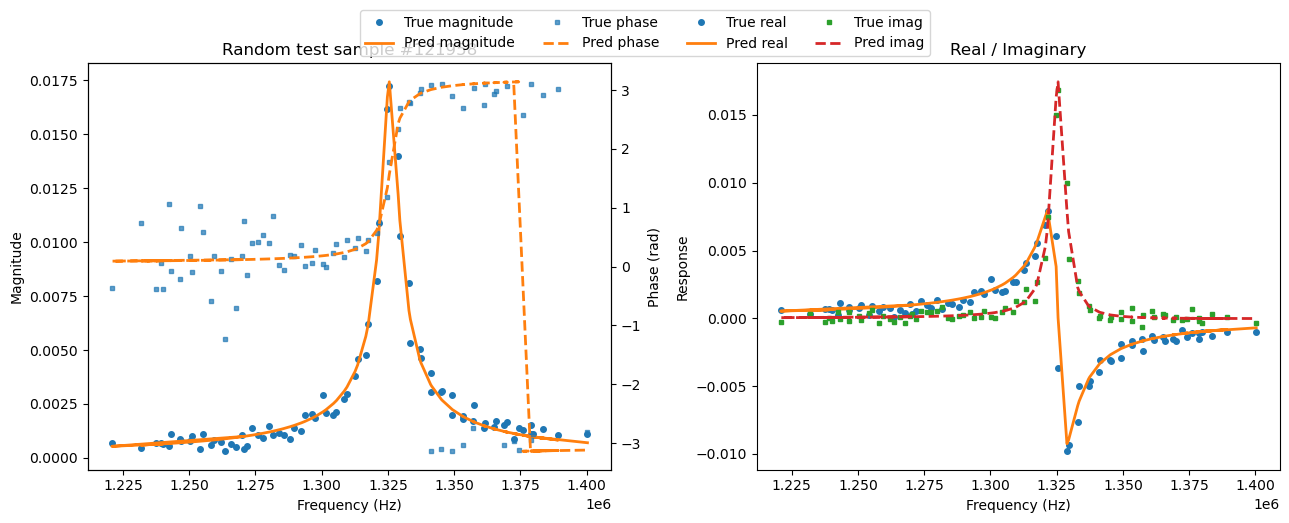

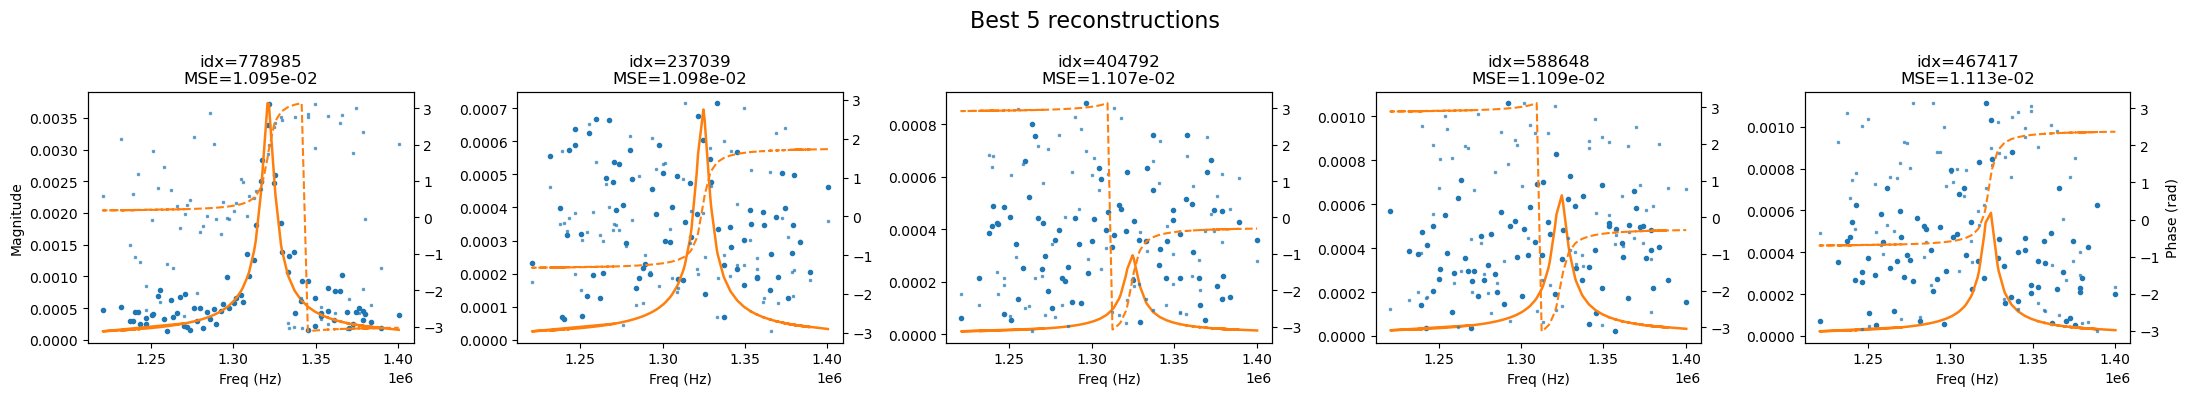

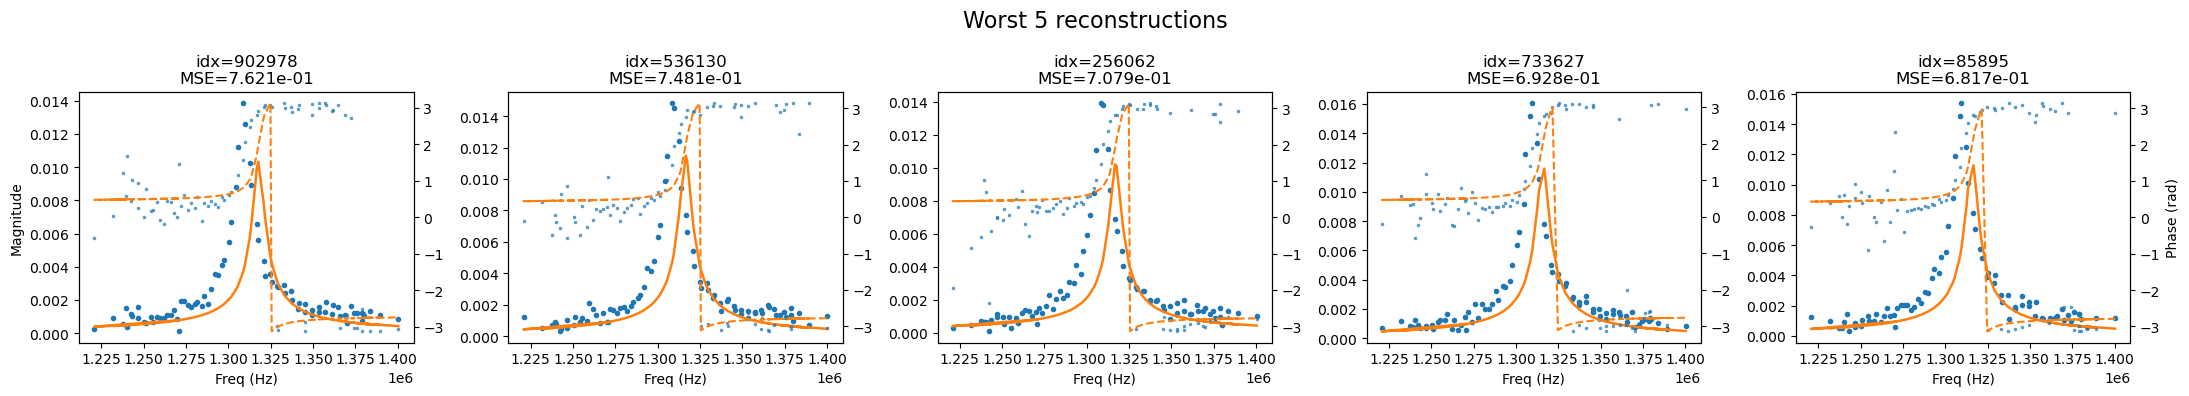

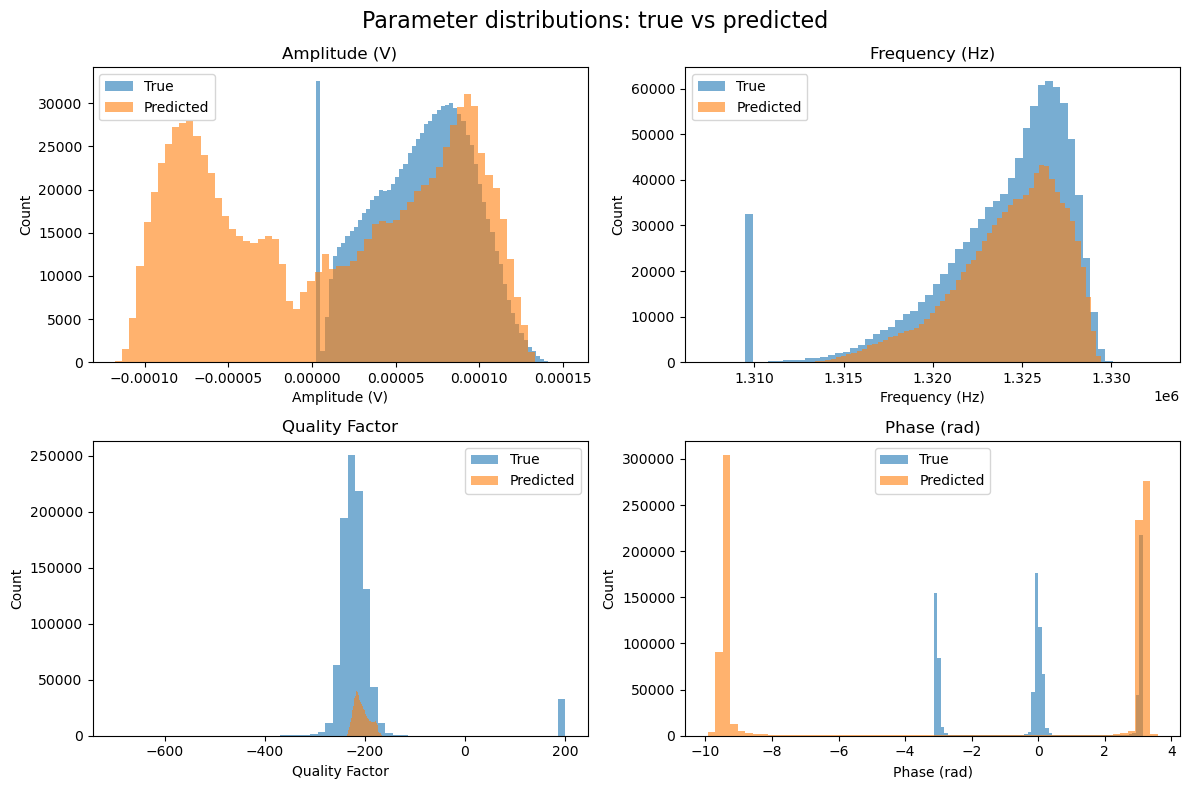

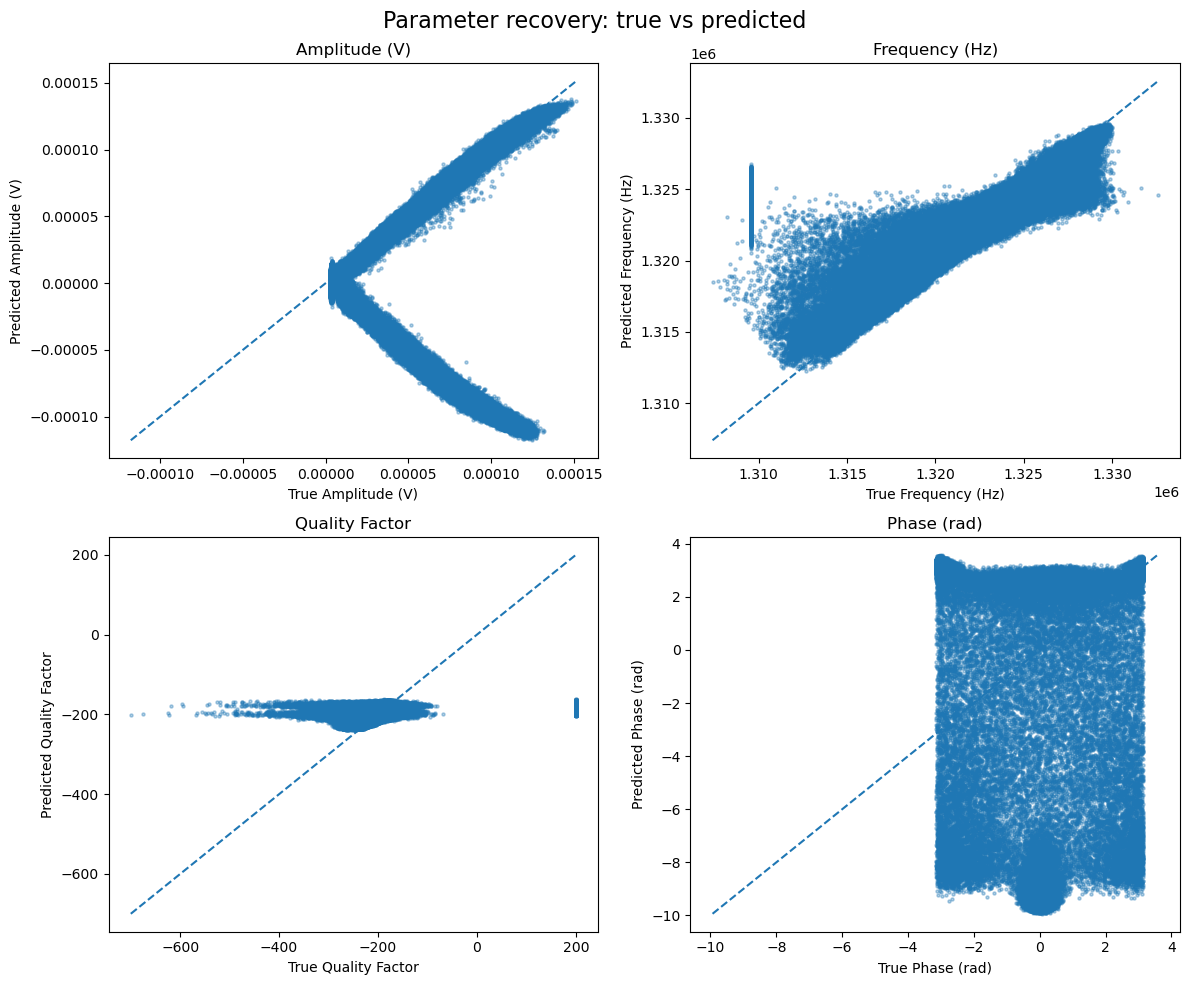

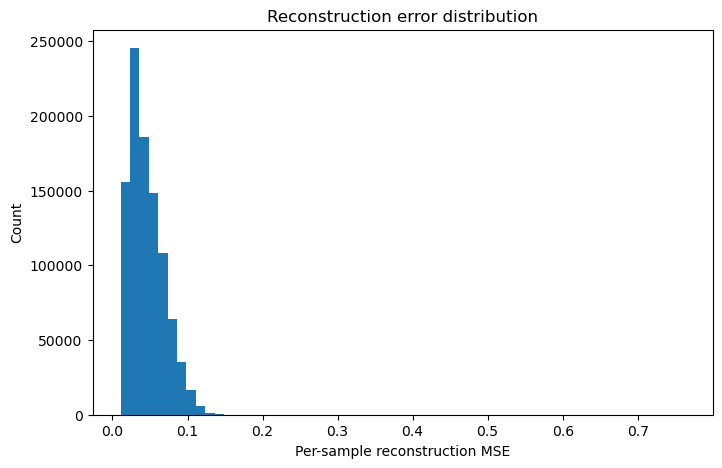

Example parameter comparisons:

Sample 778985
       Amplitude: true=2.99471e-05 | pred=1.94109e-05
       Frequency: true=1.32216e+06 | pred=1.32108e+06
  Quality Factor: true=-122.522 | pred=-193.296
           Phase: true=-2.71809 | pred=3.30236

Sample 237039
       Amplitude: true=2.77304e-06 | pred=-3.86717e-06
       Frequency: true=1.30957e+06 | pred=1.32428e+06
  Quality Factor: true=200 | pred=-181.771
           Phase: true=3.0335 | pred=-1.36025

Sample 902978
       Amplitude: true=8.27679e-05 | pred=5.45692e-05
       Frequency: true=1.30875e+06 | pred=1.31779e+06
  Quality Factor: true=-167.709 | pred=-189.708
           Phase: true=-2.96914 | pred=3.58276

Sample 536130
       Amplitude: true=8.95748e-05 | pred=6.22188e-05
       Frequency: true=1.30922e+06 | pred=1.31654e+06
  Quality Factor: true=-170.318 | pred=-184.67
           Phase: true=-2.97701 | pred=3.54658


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def complex_to_mag_phase(z):
    z = np.asarray(z)
    return np.abs(z), np.angle(z)

param_names = ["Amplitude", "Frequency", "Quality Factor", "Phase"]
param_units = ["V", "Hz", "", "rad"]

# Recompute unscaled quantities if needed
# (safe to rerun even if they already exist)
if "X_test_np" not in globals() or "predictions" not in globals():
    raise RuntimeError("Run the training/evaluation cell first so X_test_np and predictions exist.")

X_test_unscaled = np.empty_like(X_test_np, dtype=np.float64)
pred_unscaled = np.empty_like(predictions, dtype=np.float64)

X_test_unscaled[:, :, 0] = scaler_real.inverse_transform(X_test_np[:, :, 0])
X_test_unscaled[:, :, 1] = scaler_imag.inverse_transform(X_test_np[:, :, 1])

pred_unscaled[:, :, 0] = scaler_real.inverse_transform(predictions[:, :, 0])
pred_unscaled[:, :, 1] = scaler_imag.inverse_transform(predictions[:, :, 1])

X_test_complex = X_test_unscaled[:, :, 0] + 1j * X_test_unscaled[:, :, 1]
pred_complex = pred_unscaled[:, :, 0] + 1j * pred_unscaled[:, :, 1]

errors = np.mean((X_test_np - predictions) ** 2, axis=(1, 2))
best_idx = np.argsort(errors)[:5]
worst_idx = np.argsort(errors)[-5:][::-1]

# If pred_params / true_params are not present, regenerate them
if "pred_params" not in globals():
    pred_params_list = []
    model.eval()
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            pred_params_list.append(model.encode_params(xb).cpu().numpy())
    pred_params = np.vstack(pred_params_list)

if "true_params" not in globals():
    true_params = params_scaler.inverse_transform(y_test)

print("Best indices:", best_idx)
print("Worst indices:", worst_idx)

i = np.random.randint(0, len(X_test_complex))

mag_true, phase_true = complex_to_mag_phase(X_test_complex[i])
mag_pred, phase_pred = complex_to_mag_phase(pred_complex[i])

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

# Magnitude + phase
axs[0].plot(wvec_freq, mag_true, "o", markersize=4, label="True magnitude")
axs[0].plot(wvec_freq, mag_pred, "-", linewidth=2, label="Pred magnitude")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_ylabel("Magnitude")

ax2 = axs[0].twinx()
ax2.plot(wvec_freq, phase_true, "s", markersize=3, alpha=0.7, label="True phase")
ax2.plot(wvec_freq, phase_pred, "--", linewidth=2, label="Pred phase")
ax2.set_ylabel("Phase (rad)")
axs[0].set_title(f"Random test sample #{i}")

axs[1].plot(wvec_freq, X_test_unscaled[i, :, 0], "o", markersize=4, label="True real")
axs[1].plot(wvec_freq, pred_unscaled[i, :, 0], "-", linewidth=2, label="Pred real")
axs[1].plot(wvec_freq, X_test_unscaled[i, :, 1], "s", markersize=3, label="True imag")
axs[1].plot(wvec_freq, pred_unscaled[i, :, 1], "--", linewidth=2, label="Pred imag")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Response")
axs[1].set_title("Real / Imaginary")

handles1, labels1 = axs[0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = axs[1].get_legend_handles_labels()

fig.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3,
           loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05))
fig.tight_layout()
plt.show()

# Best 5 reconstructions
fig, axs = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Best 5 reconstructions", fontsize=16)

for j, idx in enumerate(best_idx):
    mag_true, phase_true = complex_to_mag_phase(X_test_complex[idx])
    mag_pred, phase_pred = complex_to_mag_phase(pred_complex[idx])

    axs[j].plot(wvec_freq, mag_true, "o", markersize=3, label="True mag")
    axs[j].plot(wvec_freq, mag_pred, "-", linewidth=1.8, label="Pred mag")
    axs[j].set_title(f"idx={idx}\nMSE={errors[idx]:.3e}")
    axs[j].set_xlabel("Freq (Hz)")
    if j == 0:
        axs[j].set_ylabel("Magnitude")

    axr = axs[j].twinx()
    axr.plot(wvec_freq, phase_true, "s", markersize=2, alpha=0.6)
    axr.plot(wvec_freq, phase_pred, "--", linewidth=1.5)
    if j == 4:
        axr.set_ylabel("Phase (rad)")

fig.tight_layout()
plt.show()

# Worst 5 reconstructions
fig, axs = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Worst 5 reconstructions", fontsize=16)

for j, idx in enumerate(worst_idx):
    mag_true, phase_true = complex_to_mag_phase(X_test_complex[idx])
    mag_pred, phase_pred = complex_to_mag_phase(pred_complex[idx])

    axs[j].plot(wvec_freq, mag_true, "o", markersize=3, label="True mag")
    axs[j].plot(wvec_freq, mag_pred, "-", linewidth=1.8, label="Pred mag")
    axs[j].set_title(f"idx={idx}\nMSE={errors[idx]:.3e}")
    axs[j].set_xlabel("Freq (Hz)")
    if j == 0:
        axs[j].set_ylabel("Magnitude")

    axr = axs[j].twinx()
    axr.plot(wvec_freq, phase_true, "s", markersize=2, alpha=0.6)
    axr.plot(wvec_freq, phase_pred, "--", linewidth=1.5)
    if j == 4:
        axr.set_ylabel("Phase (rad)")

fig.tight_layout()
plt.show()

# Parameter histograms: true vs predicted
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for k in range(4):
    axs[k].hist(true_params[:, k], bins=60, alpha=0.6, label="True")
    axs[k].hist(pred_params[:, k], bins=60, alpha=0.6, label="Predicted")
    label = f"{param_names[k]} ({param_units[k]})" if param_units[k] else param_names[k]
    axs[k].set_title(label)
    axs[k].set_xlabel(label)
    axs[k].set_ylabel("Count")
    axs[k].legend()

fig.suptitle("Parameter distributions: true vs predicted", fontsize=16)
fig.tight_layout()
plt.show()

# Parameter scatter plots: true vs predicted
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for k in range(4):
    axs[k].scatter(true_params[:, k], pred_params[:, k], s=5, alpha=0.35)
    mn = min(true_params[:, k].min(), pred_params[:, k].min())
    mx = max(true_params[:, k].max(), pred_params[:, k].max())
    axs[k].plot([mn, mx], [mn, mx], "--")
    label = f"{param_names[k]} ({param_units[k]})" if param_units[k] else param_names[k]
    axs[k].set_xlabel(f"True {label}")
    axs[k].set_ylabel(f"Predicted {label}")
    axs[k].set_title(label)

fig.suptitle("Parameter recovery: true vs predicted", fontsize=16)
fig.tight_layout()
plt.show()

# Reconstruction error histogram
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=60)
plt.xlabel("Per-sample reconstruction MSE")
plt.ylabel("Count")
plt.title("Reconstruction error distribution")
plt.show()

example_ids = [best_idx[0], best_idx[1], worst_idx[0], worst_idx[1]]
print("Example parameter comparisons:")
for idx in example_ids:
    print(f"\nSample {idx}")
    for k in range(4):
        print(f"  {param_names[k]:>14s}: true={true_params[idx, k]:.6g} | pred={pred_params[idx, k]:.6g}")

# Pure NN approach

In [3]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataloaders
batch_size = 256

train_loader_pure = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=batch_size,
    shuffle=True
)

test_loader_pure = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=4096,
    shuffle=False
)

# Pure NN model
class PureNN(nn.Module):
    def __init__(self, input_dim=160, hidden_dims=(256, 128, 64), output_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
            nn.Linear(hidden_dims[2], output_dim)
        )

    def forward(self, x):
        # x shape: [batch, 80, 2]
        x = x.reshape(x.shape[0], -1)  # [batch, 160]
        return self.net(x)             # scaled params

pure_nn = PureNN().to(device)
print(pure_nn)

# Train
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(pure_nn.parameters(), lr=1e-3)
epochs = 20

for epoch in range(epochs):
    start = time.time()
    pure_nn.train()
    running_loss = 0.0
    total = 0

    for xb, yb in train_loader_pure:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred_params_scaled = pure_nn(xb)
        loss = loss_fn(pred_params_scaled, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    epoch_loss = running_loss / total
    print(f"Epoch {epoch+1:02d}/{epochs} | param loss = {epoch_loss:.8f} | time = {time.time()-start:.2f}s")

torch.save(pure_nn.state_dict(), "pure_nn_baseline.pth")
print("Saved model to pure_nn_baseline.pth")

# Predict parameters on test set
pure_nn.eval()
pred_params_scaled_list = []

with torch.no_grad():
    for xb, _ in test_loader_pure:
        xb = xb.to(device)
        pred_params_scaled = pure_nn(xb)
        pred_params_scaled_list.append(pred_params_scaled.cpu().numpy())

pure_pred_params_scaled = np.vstack(pred_params_scaled_list)

# Convert scaled -> physical params
pure_pred_params = params_scaler.inverse_transform(pure_pred_params_scaled)
pure_true_params = params_scaler.inverse_transform(y_test)

# Reconstruct spectra from predicted params using SHO formula
pure_pred_complex_list = []

with torch.no_grad():
    for start_idx in range(0, len(pure_pred_params), 4096):
        end_idx = min(start_idx + 4096, len(pure_pred_params))
        batch_params = torch.tensor(pure_pred_params[start_idx:end_idx], dtype=torch.float64, device=device)
        batch_complex = sho_fit_func_torch(batch_params, wvec_freq, device=device)
        pure_pred_complex_list.append(batch_complex.cpu().numpy())

pure_pred_complex = np.vstack(pure_pred_complex_list)  # [N, 80] complex

pure_pred_recon = np.empty((len(pure_pred_complex), len(wvec_freq), 2), dtype=np.float32)
pure_pred_recon[:, :, 0] = ((np.real(pure_pred_complex) - scaler_real.mean) / scaler_real.std).astype(np.float32)
pure_pred_recon[:, :, 1] = ((np.imag(pure_pred_complex) - scaler_imag.mean) / scaler_imag.std).astype(np.float32)

# Ground truth in scaled space
X_test_np_pure = X_test.copy()

# Metrics in scaled reconstruction space
pure_mse_real = mean_squared_error(X_test_np_pure[:, :, 0], pure_pred_recon[:, :, 0])
pure_mse_imag = mean_squared_error(X_test_np_pure[:, :, 1], pure_pred_recon[:, :, 1])
pure_avg_mse = 0.5 * (pure_mse_real + pure_mse_imag)

print(f"MSE real: {pure_mse_real:.8e}")
print(f"MSE imag: {pure_mse_imag:.8e}")
print(f"Avg  MSE: {pure_avg_mse:.8e}")

# Parameter MSE in physical units
pure_param_mse = ((pure_pred_params - pure_true_params) ** 2).mean(axis=0)
print("Parameter MSE [Amp, w0, Q, phi]:", pure_param_mse)

# Unscaled test complex data
X_test_unscaled_pure = np.empty_like(X_test_np_pure, dtype=np.float64)
X_test_unscaled_pure[:, :, 0] = scaler_real.inverse_transform(X_test_np_pure[:, :, 0])
X_test_unscaled_pure[:, :, 1] = scaler_imag.inverse_transform(X_test_np_pure[:, :, 1])
X_test_complex_pure = X_test_unscaled_pure[:, :, 0] + 1j * X_test_unscaled_pure[:, :, 1]

# Per-sample reconstruction errors
pure_errors = np.mean((X_test_np_pure - pure_pred_recon) ** 2, axis=(1, 2))
pure_best_idx = np.argsort(pure_errors)[:5]
pure_worst_idx = np.argsort(pure_errors)[-5:][::-1]

print("Best sample indices:", pure_best_idx)
print("Worst sample indices:", pure_worst_idx)

print("\nPure NN training/evaluation done.")

PureNN(
  (net): Sequential(
    (0): Linear(in_features=160, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 01/20 | param loss = 0.15277852 | time = 8.11s
Epoch 02/20 | param loss = 0.10558872 | time = 8.60s
Epoch 03/20 | param loss = 0.09666407 | time = 8.73s
Epoch 04/20 | param loss = 0.08962100 | time = 8.42s
Epoch 05/20 | param loss = 0.08335042 | time = 8.15s
Epoch 06/20 | param loss = 0.07754066 | time = 7.21s
Epoch 07/20 | param loss = 0.07247635 | time = 6.81s
Epoch 08/20 | param loss = 0.06898796 | time = 7.32s
Epoch 09/20 | param loss = 0.06531715 | time = 7.97s
Epoch 10/20 | param loss = 0.06272131 | time = 7.88s
Epoch 11/20 | param loss = 0.06104359 | time = 6.54s
Epoch 12/20 | param loss = 0.05969570 | time = 6.76s
Epoch 13/20 | param loss = 0.05879375

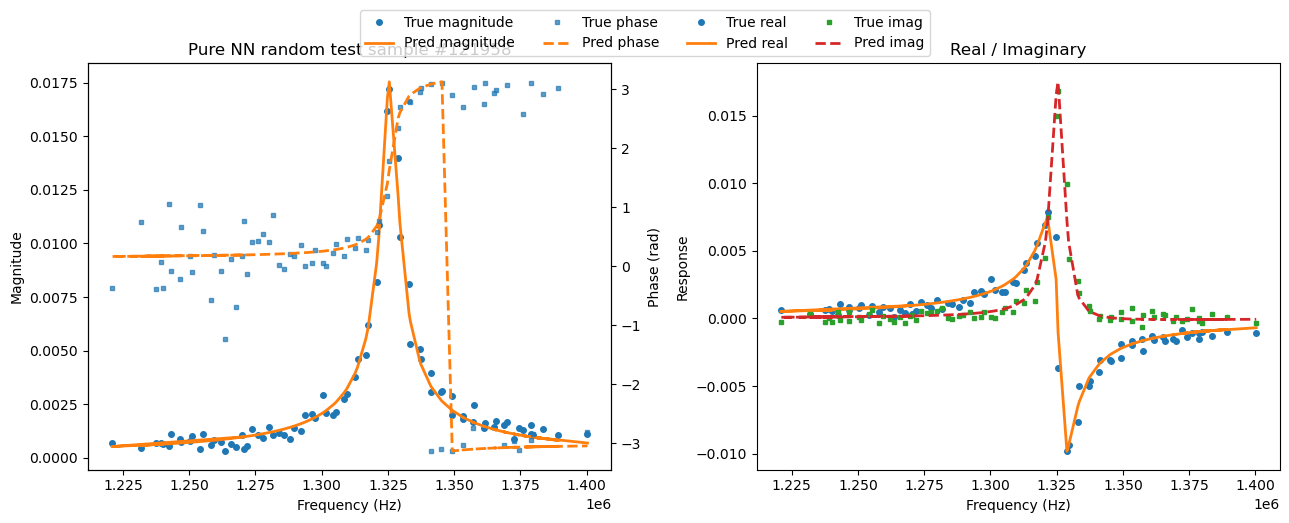

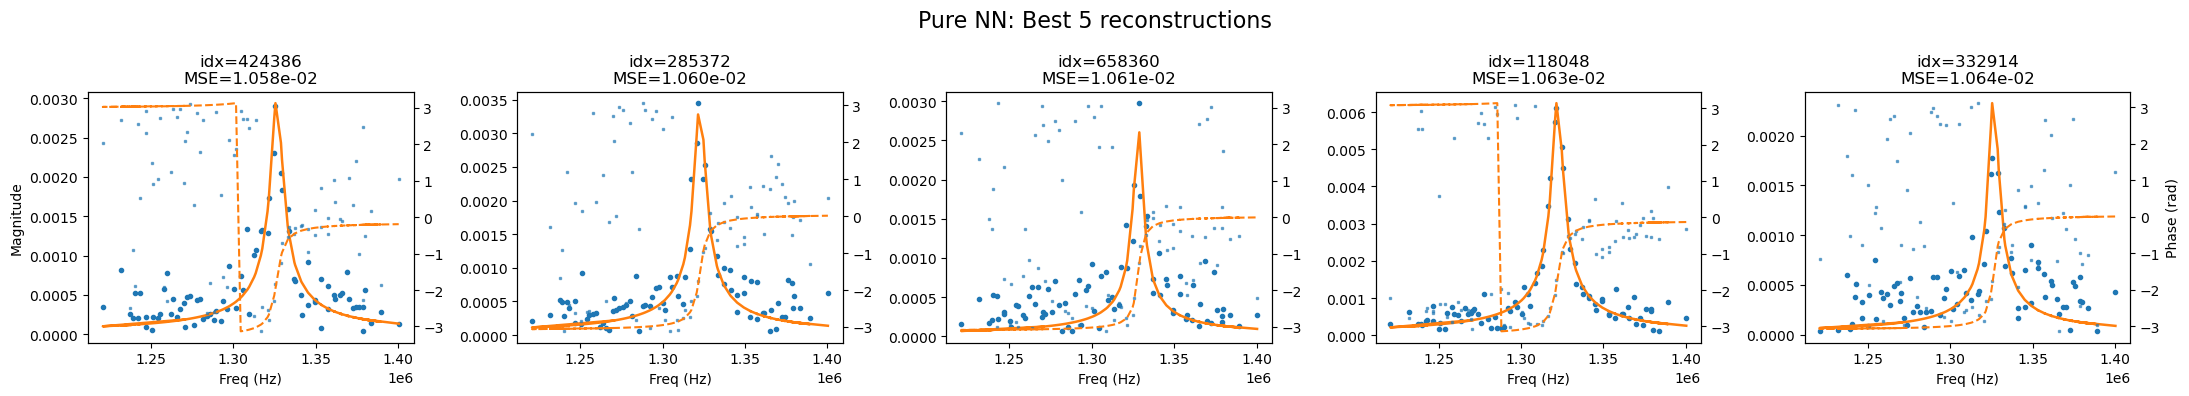

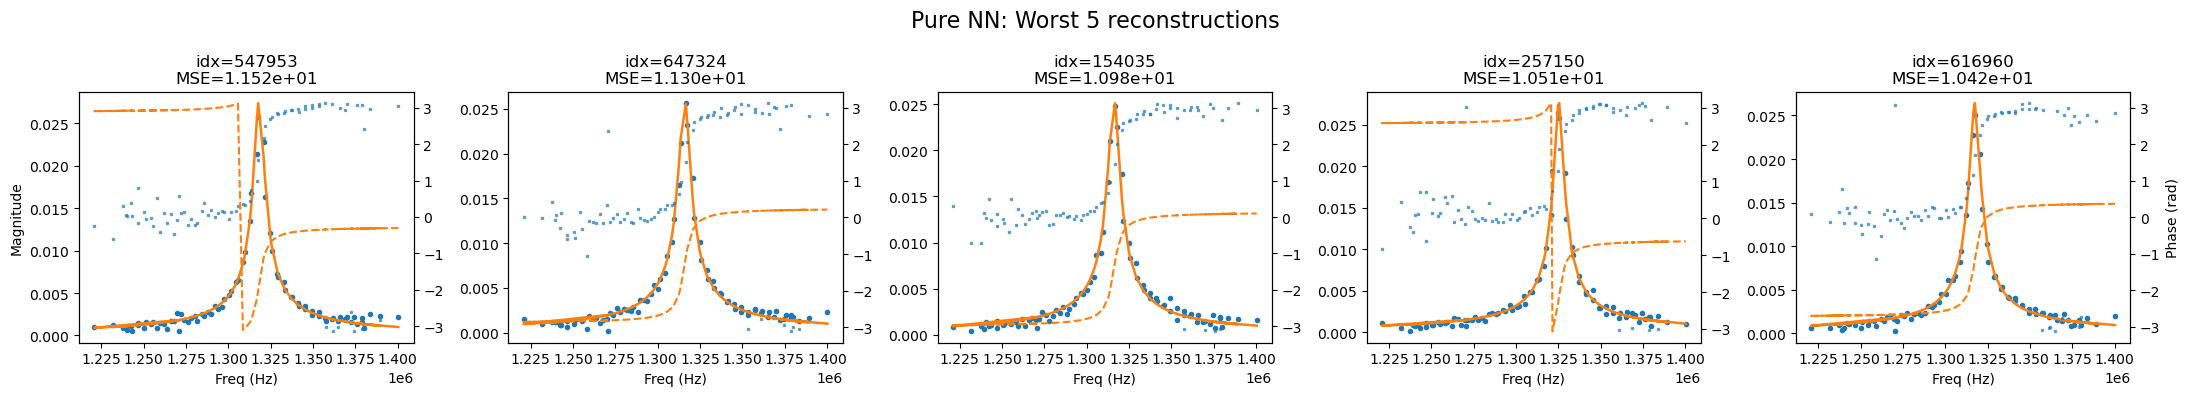

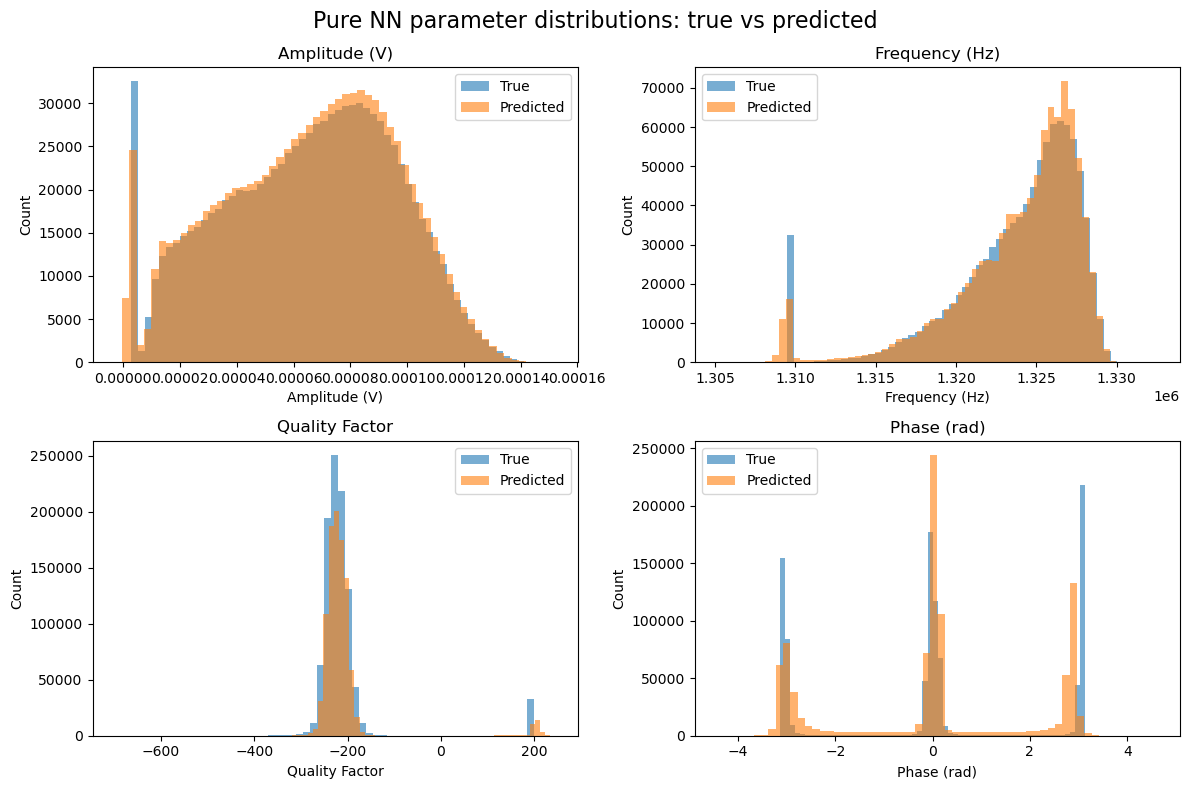

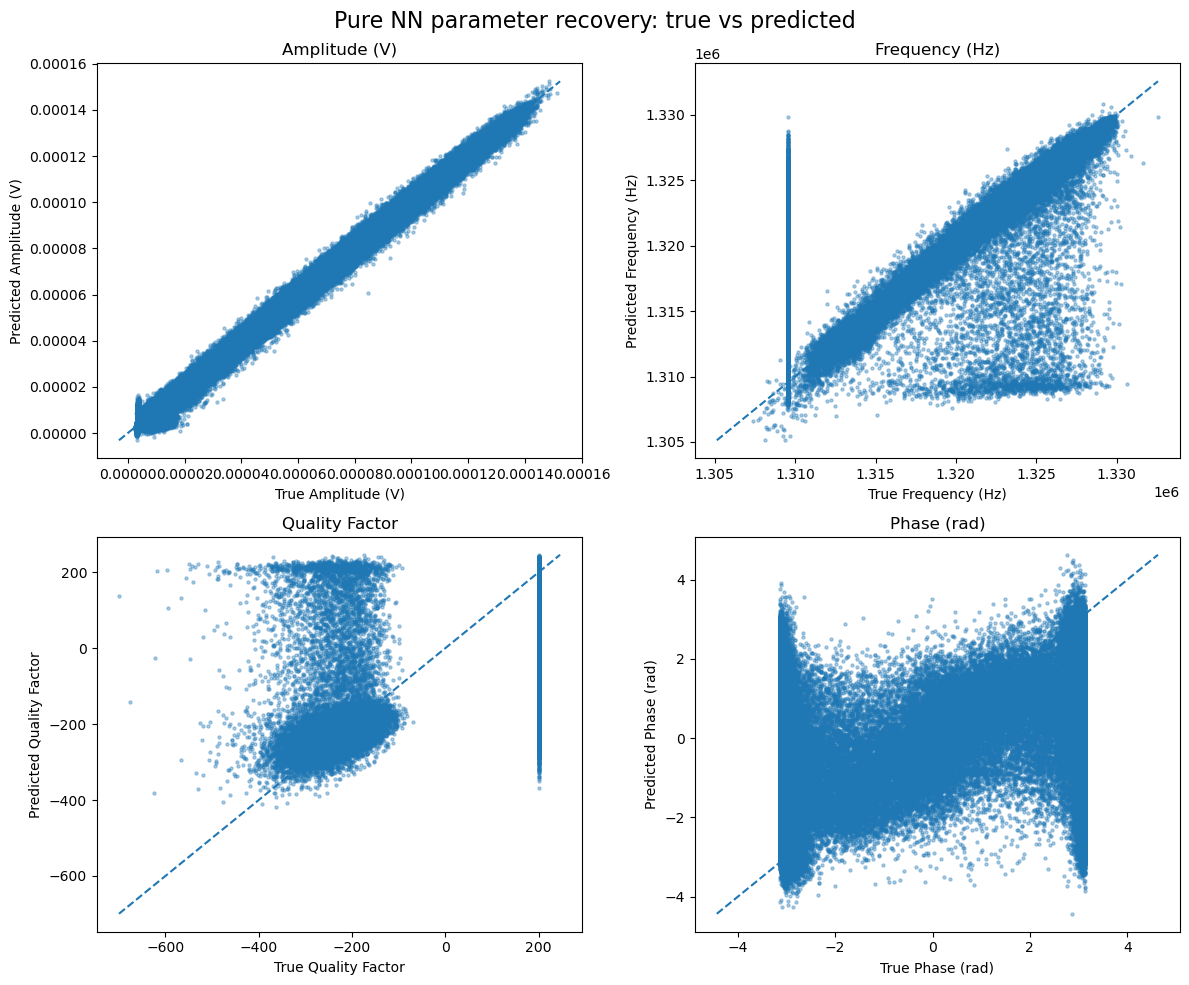

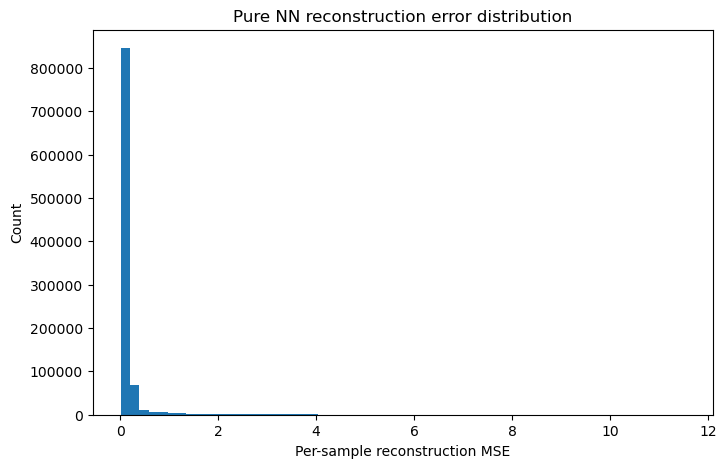

Example parameter comparisons:

Sample 424386
       Amplitude: true=1.26107e-05 | pred=1.54721e-05
       Frequency: true=1.32602e+06 | pred=1.32637e+06
  Quality Factor: true=-217.274 | pred=-195.691
           Phase: true=-0.289903 | pred=-0.145009

Sample 285372
       Amplitude: true=2.15765e-05 | pred=1.67955e-05
       Frequency: true=1.32293e+06 | pred=1.32268e+06
  Quality Factor: true=-167.392 | pred=-207.381
           Phase: true=0.0657844 | pred=0.0531239

Sample 547953
       Amplitude: true=0.000121421 | pred=0.000128667
       Frequency: true=1.31835e+06 | pred=1.31812e+06
  Quality Factor: true=-215.625 | pred=-216.557
           Phase: true=-3.0839 | pred=-0.264722

Sample 647324
       Amplitude: true=0.000133593 | pred=0.000133342
       Frequency: true=1.31643e+06 | pred=1.31586e+06
  Quality Factor: true=-193.22 | pred=-196.899
           Phase: true=-3.11739 | pred=0.25418


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def complex_to_mag_phase(z):
    z = np.asarray(z)
    return np.abs(z), np.angle(z)

param_names = ["Amplitude", "Frequency", "Quality Factor", "Phase"]
param_units = ["V", "Hz", "", "rad"]

# 1) Single random reconstruction plot
i = np.random.randint(0, len(X_test_complex_pure))

mag_true, phase_true = complex_to_mag_phase(X_test_complex_pure[i])
mag_pred, phase_pred = complex_to_mag_phase(pure_pred_complex[i])

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

# Magnitude + phase
axs[0].plot(wvec_freq, mag_true, "o", markersize=4, label="True magnitude")
axs[0].plot(wvec_freq, mag_pred, "-", linewidth=2, label="Pred magnitude")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_ylabel("Magnitude")

ax2 = axs[0].twinx()
ax2.plot(wvec_freq, phase_true, "s", markersize=3, alpha=0.7, label="True phase")
ax2.plot(wvec_freq, phase_pred, "--", linewidth=2, label="Pred phase")
ax2.set_ylabel("Phase (rad)")
axs[0].set_title(f"Pure NN random test sample #{i}")

# Real/imaginary
axs[1].plot(wvec_freq, X_test_unscaled_pure[i, :, 0], "o", markersize=4, label="True real")
axs[1].plot(wvec_freq, np.real(pure_pred_complex[i]), "-", linewidth=2, label="Pred real")
axs[1].plot(wvec_freq, X_test_unscaled_pure[i, :, 1], "s", markersize=3, label="True imag")
axs[1].plot(wvec_freq, np.imag(pure_pred_complex[i]), "--", linewidth=2, label="Pred imag")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Response")
axs[1].set_title("Real / Imaginary")

handles1, labels1 = axs[0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = axs[1].get_legend_handles_labels()

fig.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3,
           loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05))
fig.tight_layout()
plt.show()

# Best 5 reconstructions
fig, axs = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Pure NN: Best 5 reconstructions", fontsize=16)

for j, idx in enumerate(pure_best_idx):
    mag_true, phase_true = complex_to_mag_phase(X_test_complex_pure[idx])
    mag_pred, phase_pred = complex_to_mag_phase(pure_pred_complex[idx])

    axs[j].plot(wvec_freq, mag_true, "o", markersize=3, label="True mag")
    axs[j].plot(wvec_freq, mag_pred, "-", linewidth=1.8, label="Pred mag")
    axs[j].set_title(f"idx={idx}\nMSE={pure_errors[idx]:.3e}")
    axs[j].set_xlabel("Freq (Hz)")
    if j == 0:
        axs[j].set_ylabel("Magnitude")

    axr = axs[j].twinx()
    axr.plot(wvec_freq, phase_true, "s", markersize=2, alpha=0.6)
    axr.plot(wvec_freq, phase_pred, "--", linewidth=1.5)
    if j == 4:
        axr.set_ylabel("Phase (rad)")

fig.tight_layout()
plt.show()

# Worst 5 reconstructions
fig, axs = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Pure NN: Worst 5 reconstructions", fontsize=16)

for j, idx in enumerate(pure_worst_idx):
    mag_true, phase_true = complex_to_mag_phase(X_test_complex_pure[idx])
    mag_pred, phase_pred = complex_to_mag_phase(pure_pred_complex[idx])

    axs[j].plot(wvec_freq, mag_true, "o", markersize=3, label="True mag")
    axs[j].plot(wvec_freq, mag_pred, "-", linewidth=1.8, label="Pred mag")
    axs[j].set_title(f"idx={idx}\nMSE={pure_errors[idx]:.3e}")
    axs[j].set_xlabel("Freq (Hz)")
    if j == 0:
        axs[j].set_ylabel("Magnitude")

    axr = axs[j].twinx()
    axr.plot(wvec_freq, phase_true, "s", markersize=2, alpha=0.6)
    axr.plot(wvec_freq, phase_pred, "--", linewidth=1.5)
    if j == 4:
        axr.set_ylabel("Phase (rad)")

fig.tight_layout()
plt.show()

# Parameter histograms: true vs predicted
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for k in range(4):
    axs[k].hist(pure_true_params[:, k], bins=60, alpha=0.6, label="True")
    axs[k].hist(pure_pred_params[:, k], bins=60, alpha=0.6, label="Predicted")
    label = f"{param_names[k]} ({param_units[k]})" if param_units[k] else param_names[k]
    axs[k].set_title(label)
    axs[k].set_xlabel(label)
    axs[k].set_ylabel("Count")
    axs[k].legend()

fig.suptitle("Pure NN parameter distributions: true vs predicted", fontsize=16)
fig.tight_layout()
plt.show()

# Parameter scatter plots: true vs predicted
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for k in range(4):
    axs[k].scatter(pure_true_params[:, k], pure_pred_params[:, k], s=5, alpha=0.35)
    mn = min(pure_true_params[:, k].min(), pure_pred_params[:, k].min())
    mx = max(pure_true_params[:, k].max(), pure_pred_params[:, k].max())
    axs[k].plot([mn, mx], [mn, mx], "--")
    label = f"{param_names[k]} ({param_units[k]})" if param_units[k] else param_names[k]
    axs[k].set_xlabel(f"True {label}")
    axs[k].set_ylabel(f"Predicted {label}")
    axs[k].set_title(label)

fig.suptitle("Pure NN parameter recovery: true vs predicted", fontsize=16)
fig.tight_layout()
plt.show()

# Reconstruction error histogram
plt.figure(figsize=(8, 5))
plt.hist(pure_errors, bins=60)
plt.xlabel("Per-sample reconstruction MSE")
plt.ylabel("Count")
plt.title("Pure NN reconstruction error distribution")
plt.show()

# Example parameter rows
example_ids = [pure_best_idx[0], pure_best_idx[1], pure_worst_idx[0], pure_worst_idx[1]]
print("Example parameter comparisons:")
for idx in example_ids:
    print(f"\nSample {idx}")
    for k in range(4):
        print(f"  {param_names[k]:>14s}: true={pure_true_params[idx, k]:.6g} | pred={pure_pred_params[idx, k]:.6g}")

# PINN

In [5]:

import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataloaders
batch_size = 256

train_loader_pinn = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=batch_size,
    shuffle=True
)

test_loader_pinn = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=4096,
    shuffle=False
)

# PINN-style model
class PINNBaseline(nn.Module):
    def __init__(self, input_dim=160, hidden_dims=(256, 128, 64), output_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.Tanh(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.Tanh(),
            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.Tanh(),
            nn.Linear(hidden_dims[2], output_dim)
        )

    def forward(self, x):
        # x: [batch, 80, 2]
        x = x.reshape(x.shape[0], -1)
        return self.net(x)  # scaled parameters


pinn_model = PINNBaseline().to(device)
print(pinn_model)

# Helpers for scaled -> unscaled params
param_mean_t = torch.tensor(params_scaler.mean_, dtype=torch.float64, device=device)
param_std_t = torch.tensor(np.sqrt(params_scaler.var_), dtype=torch.float64, device=device)

real_mean_t = torch.tensor(scaler_real.mean, dtype=torch.float64, device=device)
real_std_t = torch.tensor(scaler_real.std, dtype=torch.float64, device=device)

imag_mean_t = torch.tensor(scaler_imag.mean, dtype=torch.float64, device=device)
imag_std_t = torch.tensor(scaler_imag.std, dtype=torch.float64, device=device)

def scaled_params_to_unscaled_torch(params_scaled):
    return params_scaled.to(torch.float64) * param_std_t.unsqueeze(0) + param_mean_t.unsqueeze(0)

def reconstruct_scaled_from_params(params_unscaled):
    """
    params_unscaled: [batch, 4] in physical units
    returns reconstructed scaled spectrum [batch, 80, 2]
    """
    fits = sho_fit_func_torch(params_unscaled, wvec_freq, device=device)  # complex [batch, 80]
    real = torch.real(fits)
    imag = torch.imag(fits)

    real_scaled = (real - real_mean_t) / real_std_t
    imag_scaled = (imag - imag_mean_t) / imag_std_t
    return torch.stack((real_scaled, imag_scaled), dim=2).to(torch.float32)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(pinn_model.parameters(), lr=1e-3)

# loss weights
lambda_param = 1.0
lambda_phys = 1.0

epochs = 20

for epoch in range(epochs):
    start = time.time()
    pinn_model.train()

    running_total = 0.0
    running_param = 0.0
    running_phys = 0.0
    total = 0

    for xb, yb in train_loader_pinn:
        xb = xb.to(device)   # scaled observed spectrum [batch, 80, 2]
        yb = yb.to(device)   # scaled params [batch, 4]

        optimizer.zero_grad()

        # Predict scaled params
        pred_params_scaled = pinn_model(xb)

        # Parameter loss
        param_loss = loss_fn(pred_params_scaled, yb)

        # Physics-informed reconstruction loss
        pred_params_unscaled = scaled_params_to_unscaled_torch(pred_params_scaled)
        recon_scaled = reconstruct_scaled_from_params(pred_params_unscaled)
        phys_loss = loss_fn(recon_scaled, xb)

        total_loss = lambda_param * param_loss + lambda_phys * phys_loss
        total_loss.backward()
        optimizer.step()

        n = xb.size(0)
        running_total += total_loss.item() * n
        running_param += param_loss.item() * n
        running_phys += phys_loss.item() * n
        total += n

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"total={running_total/total:.8f} | "
        f"param={running_param/total:.8f} | "
        f"phys={running_phys/total:.8f} | "
        f"time={time.time()-start:.2f}s"
    )

torch.save(pinn_model.state_dict(), "pinn_baseline_sho.pth")
print("Saved model to pinn_baseline_sho.pth")

pinn_model.eval()
pinn_pred_params_scaled_list = []

with torch.no_grad():
    for xb, _ in test_loader_pinn:
        xb = xb.to(device)
        pred_params_scaled = pinn_model(xb)
        pinn_pred_params_scaled_list.append(pred_params_scaled.cpu().numpy())

pinn_pred_params_scaled = np.vstack(pinn_pred_params_scaled_list)

# Convert scaled -> physical params
pinn_pred_params = params_scaler.inverse_transform(pinn_pred_params_scaled)
pinn_true_params = params_scaler.inverse_transform(y_test)

# Reconstruct spectra from predicted params
pinn_pred_complex_list = []

with torch.no_grad():
    for start_idx in range(0, len(pinn_pred_params), 4096):
        end_idx = min(start_idx + 4096, len(pinn_pred_params))
        batch_params = torch.tensor(pinn_pred_params[start_idx:end_idx], dtype=torch.float64, device=device)
        batch_complex = sho_fit_func_torch(batch_params, wvec_freq, device=device)
        pinn_pred_complex_list.append(batch_complex.cpu().numpy())

pinn_pred_complex = np.vstack(pinn_pred_complex_list)  # [N, 80] complex

# Build scaled reconstruction for apples-to-apples comparison
pinn_pred_recon = np.empty((len(pinn_pred_complex), len(wvec_freq), 2), dtype=np.float32)
pinn_pred_recon[:, :, 0] = ((np.real(pinn_pred_complex) - scaler_real.mean) / scaler_real.std).astype(np.float32)
pinn_pred_recon[:, :, 1] = ((np.imag(pinn_pred_complex) - scaler_imag.mean) / scaler_imag.std).astype(np.float32)

# Ground truth in scaled space
X_test_np_pinn = X_test.copy()

# Metrics in scaled reconstruction space
pinn_mse_real = mean_squared_error(X_test_np_pinn[:, :, 0], pinn_pred_recon[:, :, 0])
pinn_mse_imag = mean_squared_error(X_test_np_pinn[:, :, 1], pinn_pred_recon[:, :, 1])
pinn_avg_mse = 0.5 * (pinn_mse_real + pinn_mse_imag)

print(f"MSE real: {pinn_mse_real:.8e}")
print(f"MSE imag: {pinn_mse_imag:.8e}")
print(f"Avg  MSE: {pinn_avg_mse:.8e}")

# Parameter MSE in physical units
pinn_param_mse = ((pinn_pred_params - pinn_true_params) ** 2).mean(axis=0)
print("Parameter MSE [Amp, w0, Q, phi]:", pinn_param_mse)

# Unscaled complex test data
X_test_unscaled_pinn = np.empty_like(X_test_np_pinn, dtype=np.float64)
X_test_unscaled_pinn[:, :, 0] = scaler_real.inverse_transform(X_test_np_pinn[:, :, 0])
X_test_unscaled_pinn[:, :, 1] = scaler_imag.inverse_transform(X_test_np_pinn[:, :, 1])
X_test_complex_pinn = X_test_unscaled_pinn[:, :, 0] + 1j * X_test_unscaled_pinn[:, :, 1]

# Per-sample reconstruction errors
pinn_errors = np.mean((X_test_np_pinn - pinn_pred_recon) ** 2, axis=(1, 2))
pinn_best_idx = np.argsort(pinn_errors)[:5]
pinn_worst_idx = np.argsort(pinn_errors)[-5:][::-1]

print("Best sample indices:", pinn_best_idx)
print("Worst sample indices:", pinn_worst_idx)

print("\nPINN-style baseline training/evaluation done.")

PINNBaseline(
  (net): Sequential(
    (0): Linear(in_features=160, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 01/20 | total=0.52699613 | param=0.40864198 | phys=0.11835415 | time=11.12s
Epoch 02/20 | total=0.20976136 | param=0.14718871 | phys=0.06257265 | time=12.57s
Epoch 03/20 | total=0.20444923 | param=0.14747079 | phys=0.05697845 | time=11.16s
Epoch 04/20 | total=0.19550062 | param=0.14173191 | phys=0.05376872 | time=11.19s
Epoch 05/20 | total=0.35287606 | param=0.27592761 | phys=0.07694845 | time=10.94s
Epoch 06/20 | total=0.19388941 | param=0.13721560 | phys=0.05667381 | time=11.16s
Epoch 07/20 | total=0.18397027 | param=0.13047026 | phys=0.05350000 | time=11.16s
Epoch 08/20 | total=0.29649410 | param=0.23251871 | phys=0.06397539 | time=11.16s
Epoch 09/20

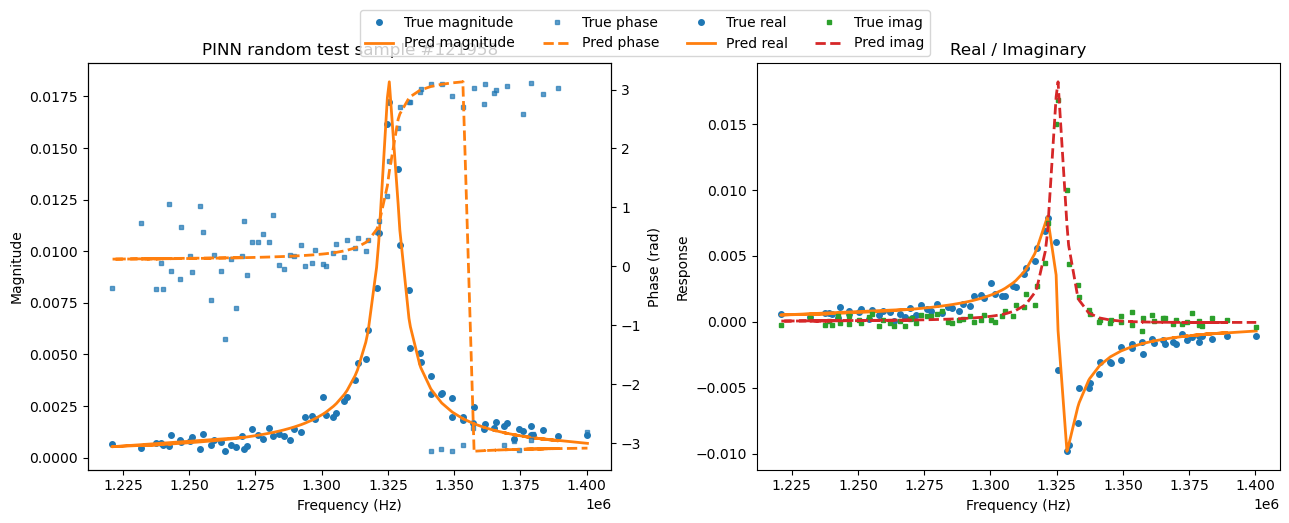

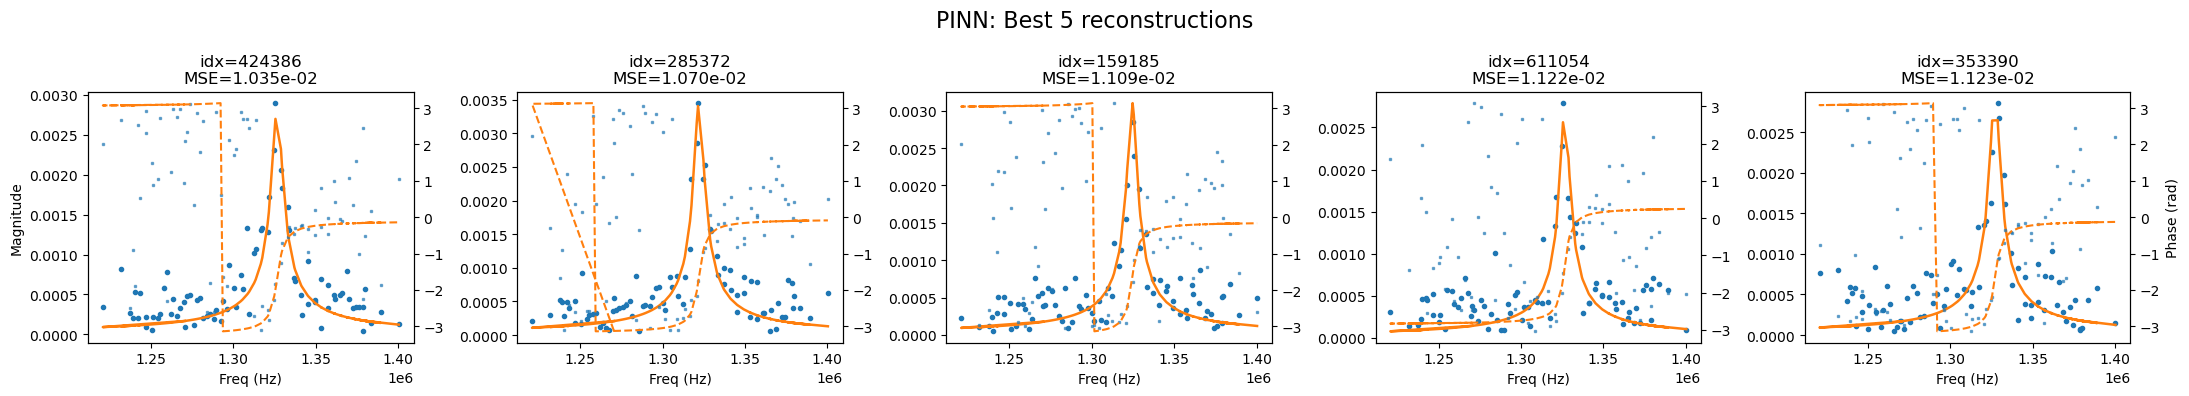

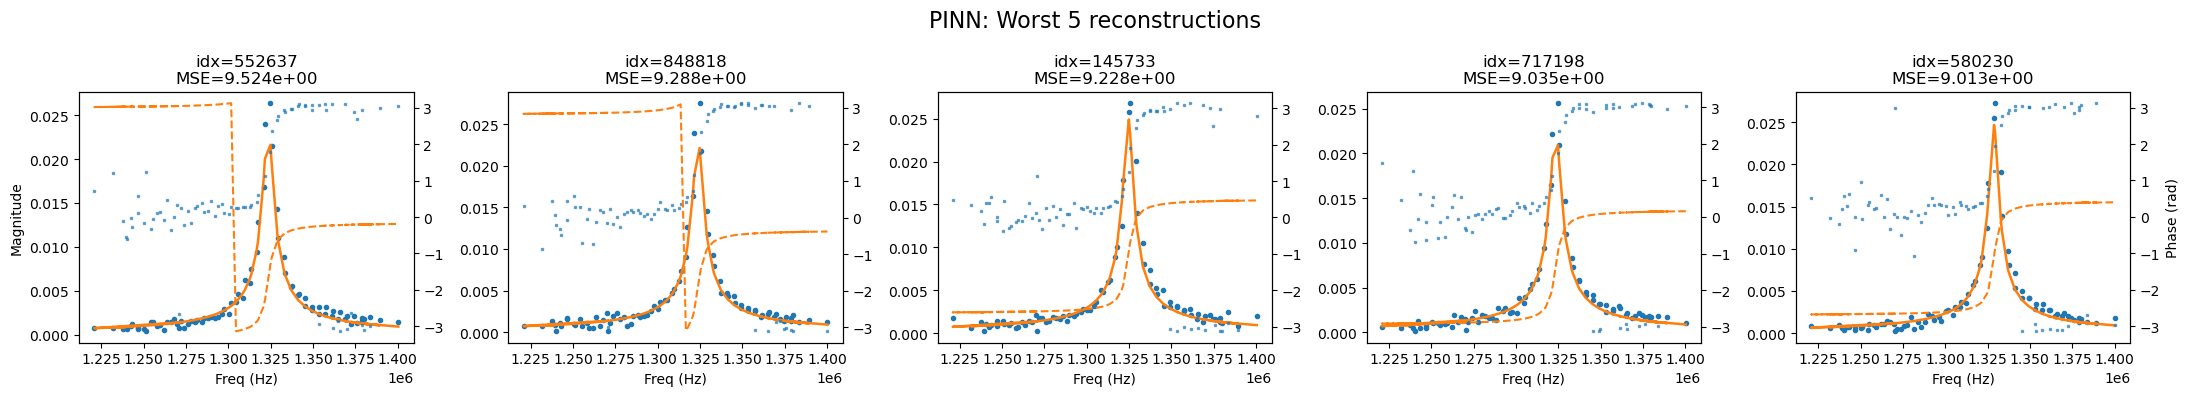

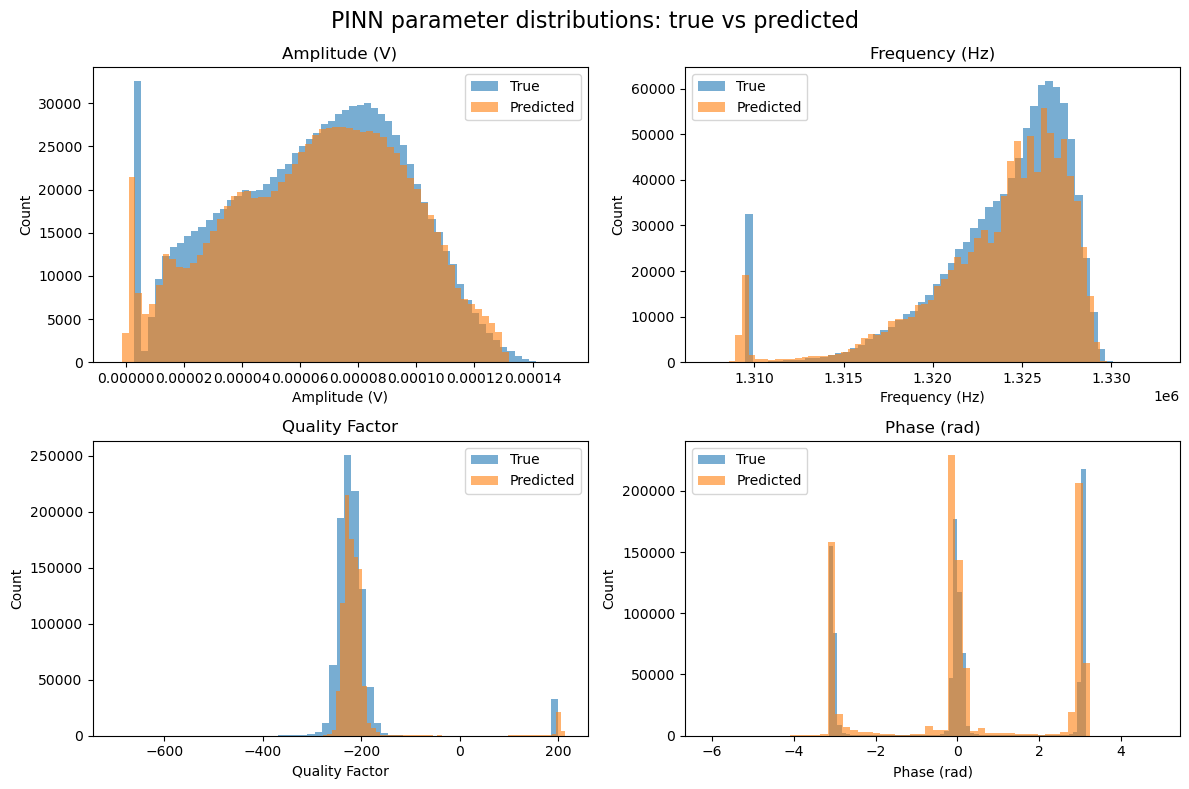

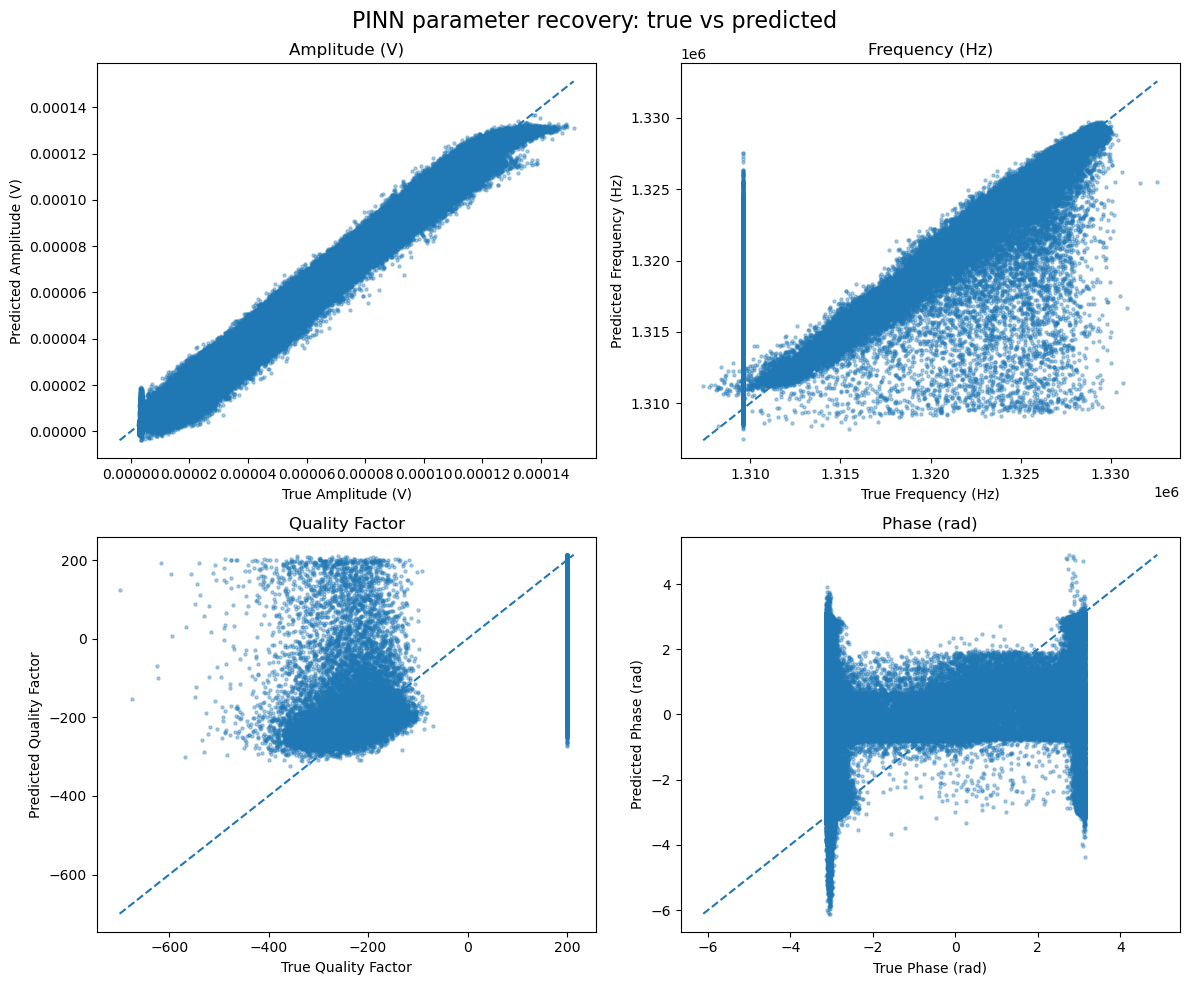

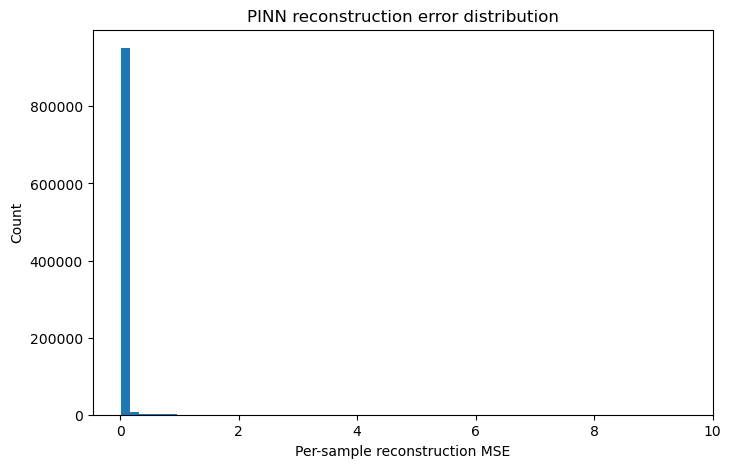

Example parameter comparisons:

Sample 424386
       Amplitude: true=1.26107e-05 | pred=1.38505e-05
       Frequency: true=1.32602e+06 | pred=1.32659e+06
  Quality Factor: true=-217.274 | pred=-205.238
           Phase: true=-0.289903 | pred=-0.0961305

Sample 285372
       Amplitude: true=2.15765e-05 | pred=1.59822e-05
       Frequency: true=1.32293e+06 | pred=1.32212e+06
  Quality Factor: true=-167.392 | pred=-216.743
           Phase: true=0.0657844 | pred=-0.0469784

Sample 552637
       Amplitude: true=0.000115707 | pred=0.000107547
       Frequency: true=1.32381e+06 | pred=1.32344e+06
  Quality Factor: true=-236.976 | pred=-220.542
           Phase: true=-3.04065 | pred=-0.14948

Sample 848818
       Amplitude: true=0.000121079 | pred=0.000107366
       Frequency: true=1.32381e+06 | pred=1.3238e+06
  Quality Factor: true=-228.885 | pred=-217.239
           Phase: true=-3.05684 | pred=-0.341455


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def complex_to_mag_phase(z):
    z = np.asarray(z)
    return np.abs(z), np.angle(z)

param_names = ["Amplitude", "Frequency", "Quality Factor", "Phase"]
param_units = ["V", "Hz", "", "rad"]

# Single random reconstruction plot
i = np.random.randint(0, len(X_test_complex_pinn))

mag_true, phase_true = complex_to_mag_phase(X_test_complex_pinn[i])
mag_pred, phase_pred = complex_to_mag_phase(pinn_pred_complex[i])

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

# Magnitude + phase
axs[0].plot(wvec_freq, mag_true, "o", markersize=4, label="True magnitude")
axs[0].plot(wvec_freq, mag_pred, "-", linewidth=2, label="Pred magnitude")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_ylabel("Magnitude")

ax2 = axs[0].twinx()
ax2.plot(wvec_freq, phase_true, "s", markersize=3, alpha=0.7, label="True phase")
ax2.plot(wvec_freq, phase_pred, "--", linewidth=2, label="Pred phase")
ax2.set_ylabel("Phase (rad)")
axs[0].set_title(f"PINN random test sample #{i}")

# Real/imaginary
axs[1].plot(wvec_freq, X_test_unscaled_pinn[i, :, 0], "o", markersize=4, label="True real")
axs[1].plot(wvec_freq, np.real(pinn_pred_complex[i]), "-", linewidth=2, label="Pred real")
axs[1].plot(wvec_freq, X_test_unscaled_pinn[i, :, 1], "s", markersize=3, label="True imag")
axs[1].plot(wvec_freq, np.imag(pinn_pred_complex[i]), "--", linewidth=2, label="Pred imag")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Response")
axs[1].set_title("Real / Imaginary")

handles1, labels1 = axs[0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = axs[1].get_legend_handles_labels()

fig.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3,
           loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05))
fig.tight_layout()
plt.show()

# Best 5 reconstructions
fig, axs = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("PINN: Best 5 reconstructions", fontsize=16)

for j, idx in enumerate(pinn_best_idx):
    mag_true, phase_true = complex_to_mag_phase(X_test_complex_pinn[idx])
    mag_pred, phase_pred = complex_to_mag_phase(pinn_pred_complex[idx])

    axs[j].plot(wvec_freq, mag_true, "o", markersize=3, label="True mag")
    axs[j].plot(wvec_freq, mag_pred, "-", linewidth=1.8, label="Pred mag")
    axs[j].set_title(f"idx={idx}\nMSE={pinn_errors[idx]:.3e}")
    axs[j].set_xlabel("Freq (Hz)")
    if j == 0:
        axs[j].set_ylabel("Magnitude")

    axr = axs[j].twinx()
    axr.plot(wvec_freq, phase_true, "s", markersize=2, alpha=0.6)
    axr.plot(wvec_freq, phase_pred, "--", linewidth=1.5)
    if j == 4:
        axr.set_ylabel("Phase (rad)")

fig.tight_layout()
plt.show()

# Worst 5 reconstructions
fig, axs = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("PINN: Worst 5 reconstructions", fontsize=16)

for j, idx in enumerate(pinn_worst_idx):
    mag_true, phase_true = complex_to_mag_phase(X_test_complex_pinn[idx])
    mag_pred, phase_pred = complex_to_mag_phase(pinn_pred_complex[idx])

    axs[j].plot(wvec_freq, mag_true, "o", markersize=3, label="True mag")
    axs[j].plot(wvec_freq, mag_pred, "-", linewidth=1.8, label="Pred mag")
    axs[j].set_title(f"idx={idx}\nMSE={pinn_errors[idx]:.3e}")
    axs[j].set_xlabel("Freq (Hz)")
    if j == 0:
        axs[j].set_ylabel("Magnitude")

    axr = axs[j].twinx()
    axr.plot(wvec_freq, phase_true, "s", markersize=2, alpha=0.6)
    axr.plot(wvec_freq, phase_pred, "--", linewidth=1.5)
    if j == 4:
        axr.set_ylabel("Phase (rad)")

fig.tight_layout()
plt.show()

# Parameter histograms: true vs predicted
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for k in range(4):
    axs[k].hist(pinn_true_params[:, k], bins=60, alpha=0.6, label="True")
    axs[k].hist(pinn_pred_params[:, k], bins=60, alpha=0.6, label="Predicted")
    label = f"{param_names[k]} ({param_units[k]})" if param_units[k] else param_names[k]
    axs[k].set_title(label)
    axs[k].set_xlabel(label)
    axs[k].set_ylabel("Count")
    axs[k].legend()

fig.suptitle("PINN parameter distributions: true vs predicted", fontsize=16)
fig.tight_layout()
plt.show()

# Parameter scatter plots: true vs predicted
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for k in range(4):
    axs[k].scatter(pinn_true_params[:, k], pinn_pred_params[:, k], s=5, alpha=0.35)
    mn = min(pinn_true_params[:, k].min(), pinn_pred_params[:, k].min())
    mx = max(pinn_true_params[:, k].max(), pinn_pred_params[:, k].max())
    axs[k].plot([mn, mx], [mn, mx], "--")
    label = f"{param_names[k]} ({param_units[k]})" if param_units[k] else param_names[k]
    axs[k].set_xlabel(f"True {label}")
    axs[k].set_ylabel(f"Predicted {label}")
    axs[k].set_title(label)

fig.suptitle("PINN parameter recovery: true vs predicted", fontsize=16)
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(pinn_errors, bins=60)
plt.xlabel("Per-sample reconstruction MSE")
plt.ylabel("Count")
plt.title("PINN reconstruction error distribution")
plt.show()

# Example parameter rows
example_ids = [pinn_best_idx[0], pinn_best_idx[1], pinn_worst_idx[0], pinn_worst_idx[1]]
print("Example parameter comparisons:")
for idx in example_ids:
    print(f"\nSample {idx}")
    for k in range(4):
        print(f"  {param_names[k]:>14s}: true={pinn_true_params[idx, k]:.6g} | pred={pinn_pred_params[idx, k]:.6g}")

# Neural ODE

In [7]:
try:
    from torchdiffeq import odeint
except ImportError:
    !pip -q install torchdiffeq
    from torchdiffeq import odeint

import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

batch_size = 256

train_loader_node = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=batch_size,
    shuffle=True
)

test_loader_node = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=4096,
    shuffle=False
)

class ODEFunc(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.Tanh(),
            nn.Linear(latent_dim, latent_dim),
            nn.Tanh(),
            nn.Linear(latent_dim, latent_dim)
        )

    def forward(self, t, z):
        return self.net(z)


class NeuralODEBaseline(nn.Module):
    def __init__(self, input_dim=160, latent_dim=64, output_dim=4):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.Tanh(),
            nn.Linear(128, latent_dim)
        )

        self.odefunc = ODEFunc(latent_dim=latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.Tanh(),
            nn.Linear(64, output_dim)
        )

        # integration time points
        self.register_buffer("integration_time", torch.tensor([0.0, 1.0], dtype=torch.float32))

    def forward(self, x):
        # x: [batch, 80, 2]
        x = x.reshape(x.shape[0], -1)       # [batch, 160]
        z0 = self.encoder(x)                # [batch, latent_dim]
        zt = odeint(self.odefunc, z0, self.integration_time, method="dopri5")
        zT = zt[-1]                         # final latent state
        return self.decoder(zT)             # [batch, 4] scaled params


node_model = NeuralODEBaseline().to(device)
print(node_model)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(node_model.parameters(), lr=1e-3)
epochs = 20

for epoch in range(epochs):
    start = time.time()
    node_model.train()
    running_loss = 0.0
    total = 0

    for xb, yb in train_loader_node:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred_params_scaled = node_model(xb)
        loss = loss_fn(pred_params_scaled, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    epoch_loss = running_loss / total
    print(f"Epoch {epoch+1:02d}/{epochs} | param loss = {epoch_loss:.8f} | time = {time.time()-start:.2f}s")

torch.save(node_model.state_dict(), "neural_ode_baseline_sho.pth")
print("Saved model to neural_ode_baseline_sho.pth")

node_model.eval()
node_pred_params_scaled_list = []

with torch.no_grad():
    for xb, _ in test_loader_node:
        xb = xb.to(device)
        pred_params_scaled = node_model(xb)
        node_pred_params_scaled_list.append(pred_params_scaled.cpu().numpy())

node_pred_params_scaled = np.vstack(node_pred_params_scaled_list)

# Convert scaled -> physical params
node_pred_params = params_scaler.inverse_transform(node_pred_params_scaled)
node_true_params = params_scaler.inverse_transform(y_test)

node_pred_complex_list = []

with torch.no_grad():
    for start_idx in range(0, len(node_pred_params), 4096):
        end_idx = min(start_idx + 4096, len(node_pred_params))
        batch_params = torch.tensor(node_pred_params[start_idx:end_idx], dtype=torch.float64, device=device)
        batch_complex = sho_fit_func_torch(batch_params, wvec_freq, device=device)
        node_pred_complex_list.append(batch_complex.cpu().numpy())

node_pred_complex = np.vstack(node_pred_complex_list)  # [N, 80] complex

node_pred_recon = np.empty((len(node_pred_complex), len(wvec_freq), 2), dtype=np.float32)
node_pred_recon[:, :, 0] = ((np.real(node_pred_complex) - scaler_real.mean) / scaler_real.std).astype(np.float32)
node_pred_recon[:, :, 1] = ((np.imag(node_pred_complex) - scaler_imag.mean) / scaler_imag.std).astype(np.float32)

# Ground truth in scaled space
X_test_np_node = X_test.copy()

# Metrics in scaled reconstruction space
node_mse_real = mean_squared_error(X_test_np_node[:, :, 0], node_pred_recon[:, :, 0])
node_mse_imag = mean_squared_error(X_test_np_node[:, :, 1], node_pred_recon[:, :, 1])
node_avg_mse = 0.5 * (node_mse_real + node_mse_imag)

print(f"MSE real: {node_mse_real:.8e}")
print(f"MSE imag: {node_mse_imag:.8e}")
print(f"Avg  MSE: {node_avg_mse:.8e}")

# Parameter MSE in physical units
node_param_mse = ((node_pred_params - node_true_params) ** 2).mean(axis=0)
print("Parameter MSE [Amp, w0, Q, phi]:", node_param_mse)

X_test_unscaled_node = np.empty_like(X_test_np_node, dtype=np.float64)
X_test_unscaled_node[:, :, 0] = scaler_real.inverse_transform(X_test_np_node[:, :, 0])
X_test_unscaled_node[:, :, 1] = scaler_imag.inverse_transform(X_test_np_node[:, :, 1])
X_test_complex_node = X_test_unscaled_node[:, :, 0] + 1j * X_test_unscaled_node[:, :, 1]

# Per-sample reconstruction errors
node_errors = np.mean((X_test_np_node - node_pred_recon) ** 2, axis=(1, 2))
node_best_idx = np.argsort(node_errors)[:5]
node_worst_idx = np.argsort(node_errors)[-5:][::-1]

print("Best sample indices:", node_best_idx)
print("Worst sample indices:", node_worst_idx)

print("\nNeural ODE baseline training/evaluation done.")

NeuralODEBaseline(
  (encoder): Sequential(
    (0): Linear(in_features=160, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
  )
  (odefunc): ODEFunc(
    (net): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)
Epoch 01/20 | param loss = 0.16388997 | time = 213.74s
Epoch 02/20 | param loss = 0.11678906 | time = 220.49s
Epoch 03/20 | param loss = 0.11023272 | time = 230.58s
Epoch 04/20 | param loss = 0.10560994 | time = 236.94s
Epoch 05/20 | param loss = 0.10191290 | time = 247.12s
Epoch 06/20 | param loss = 0.09951519 | time = 267.11s
Epoch 07/20 | param loss = 0.09697020 | 

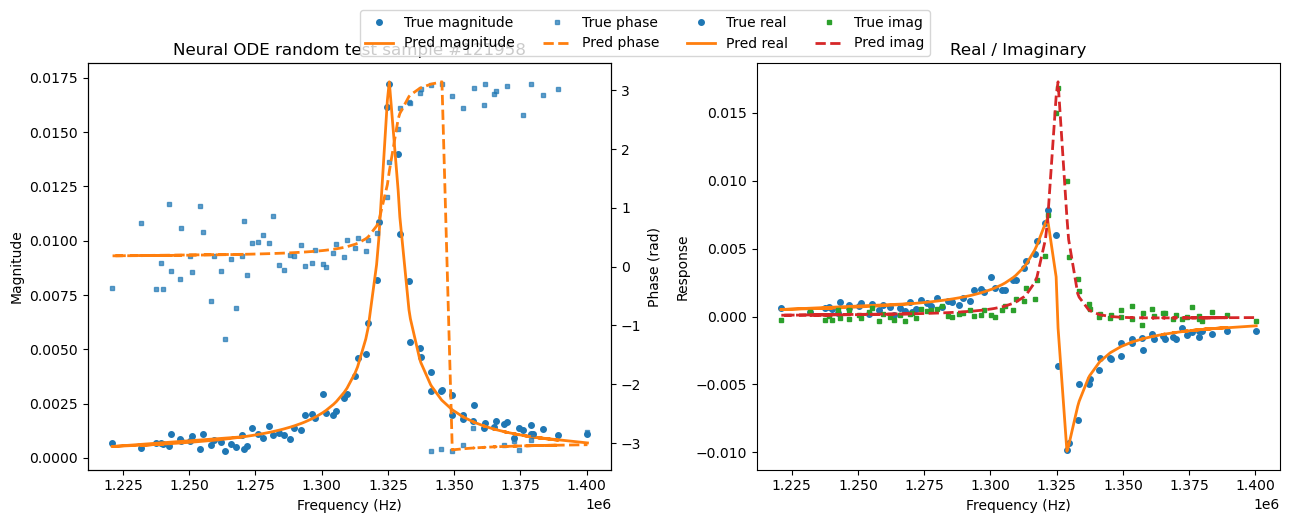

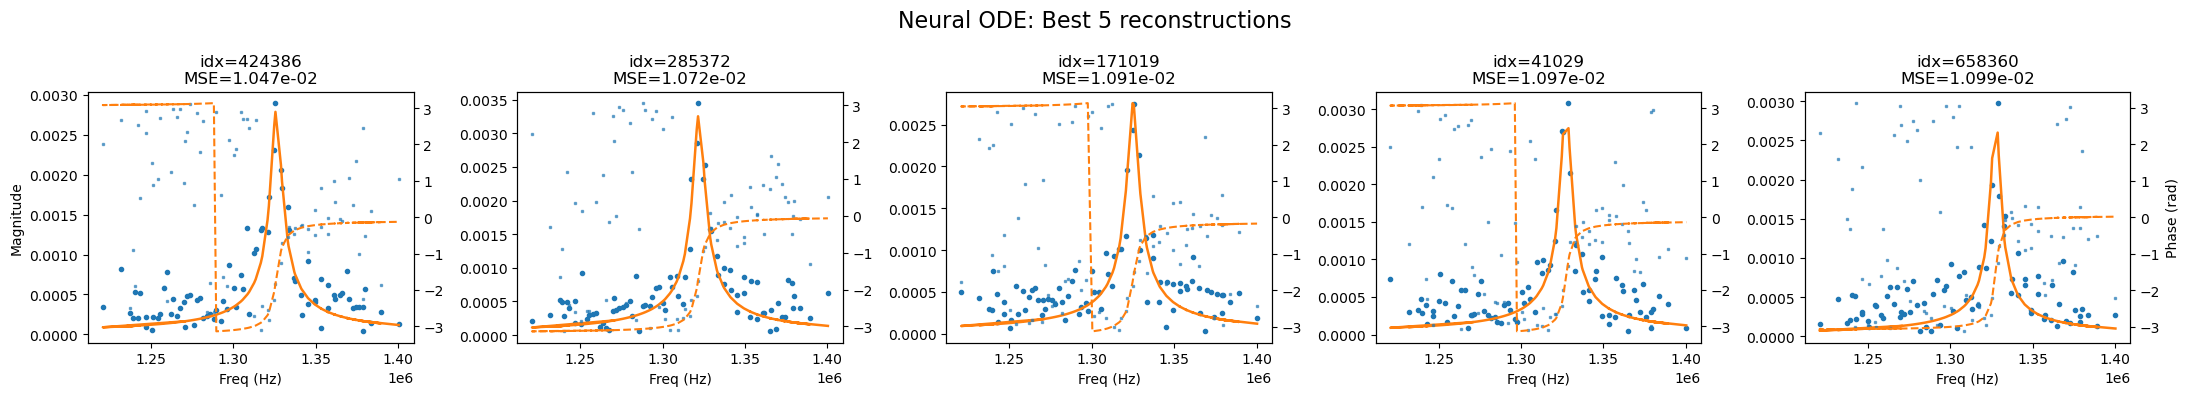

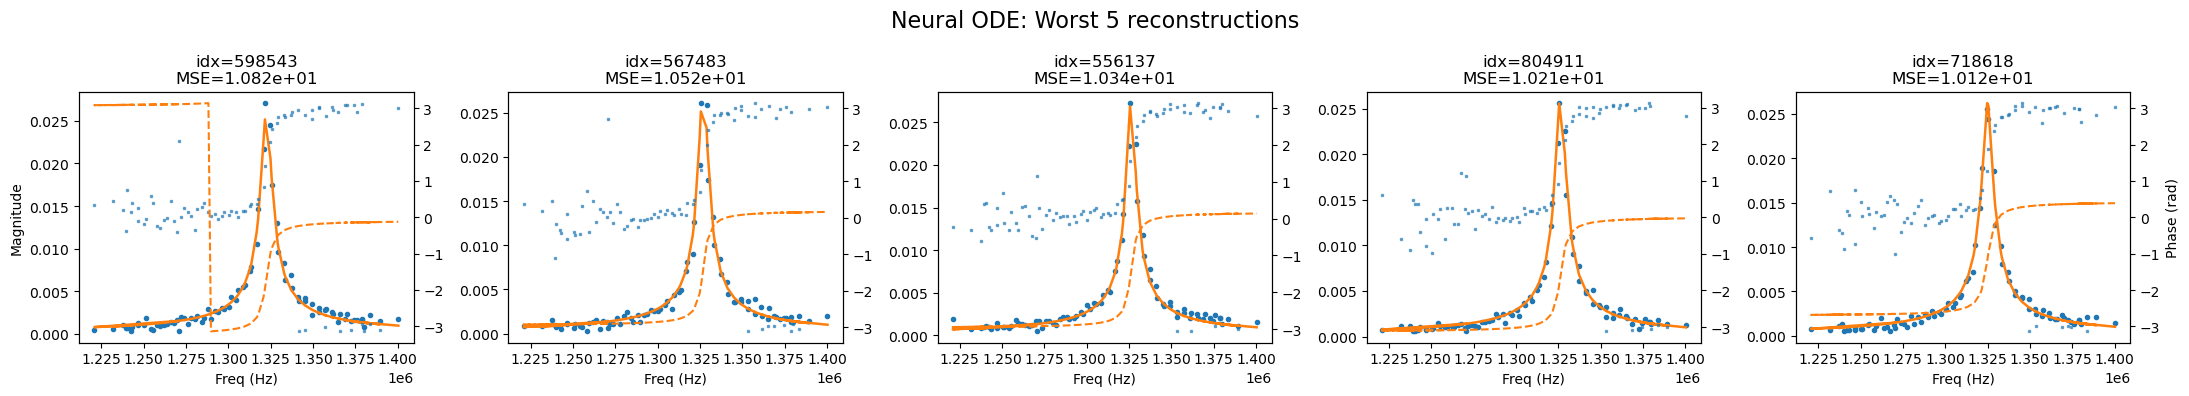

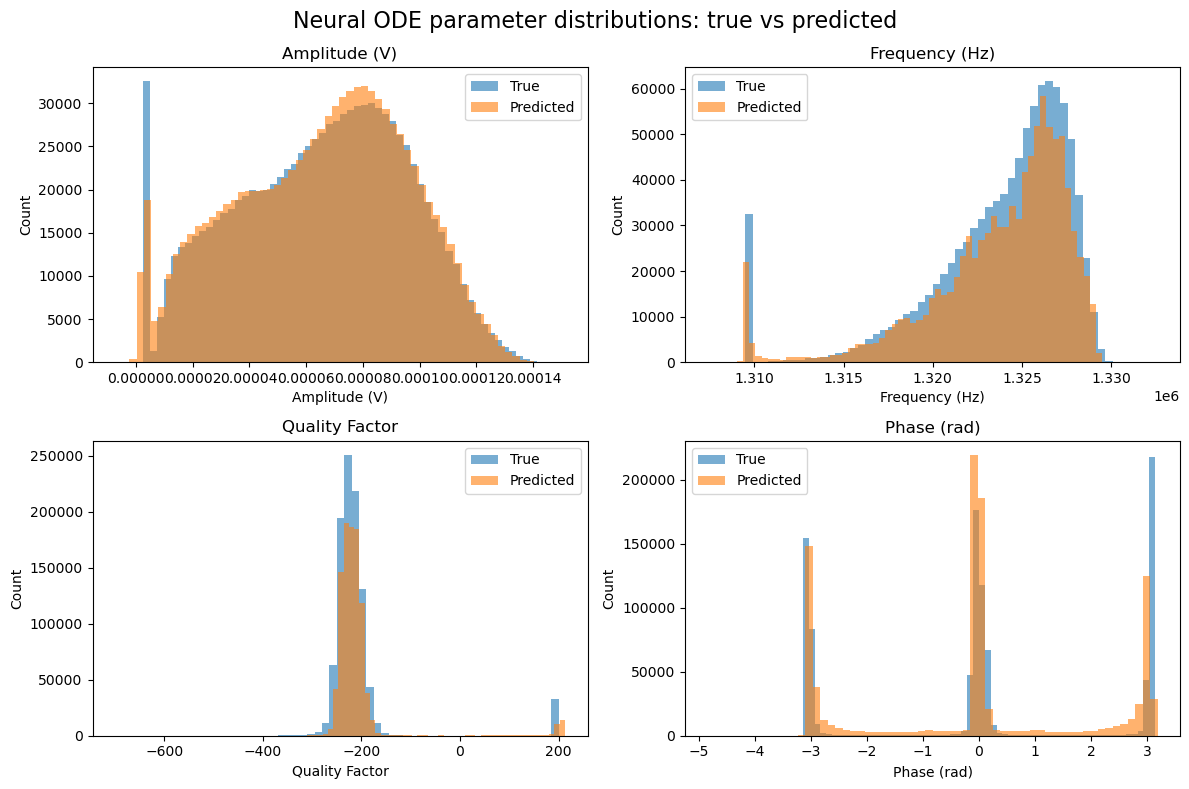

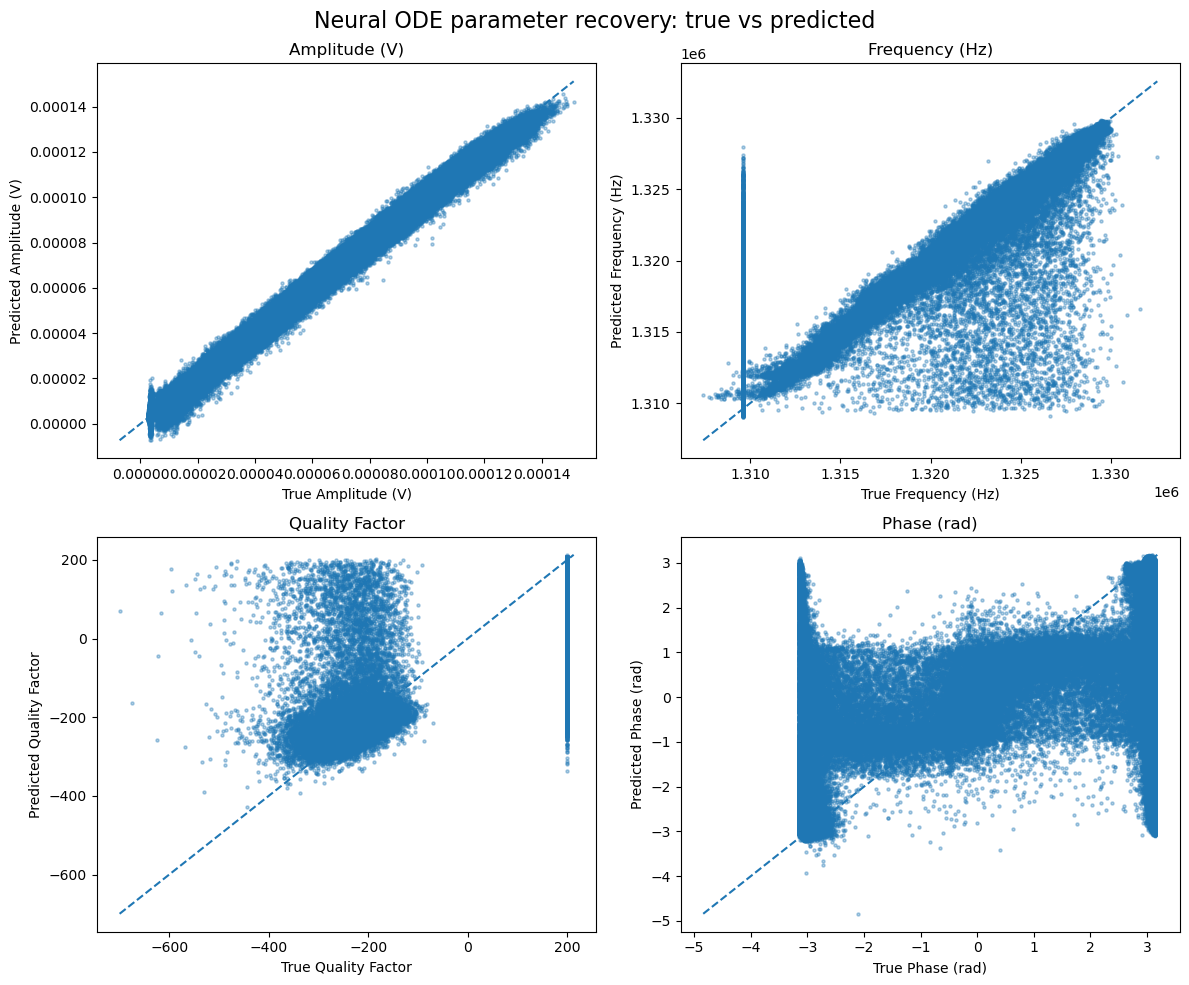

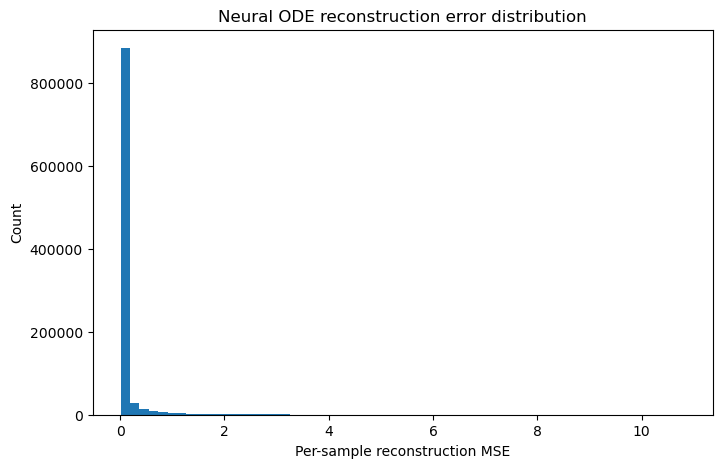

Example parameter comparisons:

Sample 424386
       Amplitude: true=1.26107e-05 | pred=1.34036e-05
       Frequency: true=1.32602e+06 | pred=1.32609e+06
  Quality Factor: true=-217.274 | pred=-211.4
           Phase: true=-0.289903 | pred=-0.084611

Sample 285372
       Amplitude: true=2.15765e-05 | pred=1.66815e-05
       Frequency: true=1.32293e+06 | pred=1.32208e+06
  Quality Factor: true=-167.392 | pred=-197.454
           Phase: true=0.0657844 | pred=-0.0238214

Sample 598543
       Amplitude: true=0.000118624 | pred=0.000117019
       Frequency: true=1.32249e+06 | pred=1.32246e+06
  Quality Factor: true=-233.957 | pred=-225.306
           Phase: true=3.11978 | pred=-0.0846665

Sample 567483
       Amplitude: true=0.000111313 | pred=0.000113397
       Frequency: true=1.32697e+06 | pred=1.32698e+06
  Quality Factor: true=-247.033 | pred=-254.008
           Phase: true=3.13993 | pred=0.196285


In [8]:

import numpy as np
import matplotlib.pyplot as plt

def complex_to_mag_phase(z):
    z = np.asarray(z)
    return np.abs(z), np.angle(z)

param_names = ["Amplitude", "Frequency", "Quality Factor", "Phase"]
param_units = ["V", "Hz", "", "rad"]

i = np.random.randint(0, len(X_test_complex_node))

mag_true, phase_true = complex_to_mag_phase(X_test_complex_node[i])
mag_pred, phase_pred = complex_to_mag_phase(node_pred_complex[i])

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

# Magnitude + phase
axs[0].plot(wvec_freq, mag_true, "o", markersize=4, label="True magnitude")
axs[0].plot(wvec_freq, mag_pred, "-", linewidth=2, label="Pred magnitude")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_ylabel("Magnitude")

ax2 = axs[0].twinx()
ax2.plot(wvec_freq, phase_true, "s", markersize=3, alpha=0.7, label="True phase")
ax2.plot(wvec_freq, phase_pred, "--", linewidth=2, label="Pred phase")
ax2.set_ylabel("Phase (rad)")
axs[0].set_title(f"Neural ODE random test sample #{i}")

# Real/imaginary
axs[1].plot(wvec_freq, X_test_unscaled_node[i, :, 0], "o", markersize=4, label="True real")
axs[1].plot(wvec_freq, np.real(node_pred_complex[i]), "-", linewidth=2, label="Pred real")
axs[1].plot(wvec_freq, X_test_unscaled_node[i, :, 1], "s", markersize=3, label="True imag")
axs[1].plot(wvec_freq, np.imag(node_pred_complex[i]), "--", linewidth=2, label="Pred imag")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Response")
axs[1].set_title("Real / Imaginary")

handles1, labels1 = axs[0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = axs[1].get_legend_handles_labels()

fig.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3,
           loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05))
fig.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Neural ODE: Best 5 reconstructions", fontsize=16)

for j, idx in enumerate(node_best_idx):
    mag_true, phase_true = complex_to_mag_phase(X_test_complex_node[idx])
    mag_pred, phase_pred = complex_to_mag_phase(node_pred_complex[idx])

    axs[j].plot(wvec_freq, mag_true, "o", markersize=3, label="True mag")
    axs[j].plot(wvec_freq, mag_pred, "-", linewidth=1.8, label="Pred mag")
    axs[j].set_title(f"idx={idx}\nMSE={node_errors[idx]:.3e}")
    axs[j].set_xlabel("Freq (Hz)")
    if j == 0:
        axs[j].set_ylabel("Magnitude")

    axr = axs[j].twinx()
    axr.plot(wvec_freq, phase_true, "s", markersize=2, alpha=0.6)
    axr.plot(wvec_freq, phase_pred, "--", linewidth=1.5)
    if j == 4:
        axr.set_ylabel("Phase (rad)")

fig.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Neural ODE: Worst 5 reconstructions", fontsize=16)

for j, idx in enumerate(node_worst_idx):
    mag_true, phase_true = complex_to_mag_phase(X_test_complex_node[idx])
    mag_pred, phase_pred = complex_to_mag_phase(node_pred_complex[idx])

    axs[j].plot(wvec_freq, mag_true, "o", markersize=3, label="True mag")
    axs[j].plot(wvec_freq, mag_pred, "-", linewidth=1.8, label="Pred mag")
    axs[j].set_title(f"idx={idx}\nMSE={node_errors[idx]:.3e}")
    axs[j].set_xlabel("Freq (Hz)")
    if j == 0:
        axs[j].set_ylabel("Magnitude")

    axr = axs[j].twinx()
    axr.plot(wvec_freq, phase_true, "s", markersize=2, alpha=0.6)
    axr.plot(wvec_freq, phase_pred, "--", linewidth=1.5)
    if j == 4:
        axr.set_ylabel("Phase (rad)")

fig.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for k in range(4):
    axs[k].hist(node_true_params[:, k], bins=60, alpha=0.6, label="True")
    axs[k].hist(node_pred_params[:, k], bins=60, alpha=0.6, label="Predicted")
    label = f"{param_names[k]} ({param_units[k]})" if param_units[k] else param_names[k]
    axs[k].set_title(label)
    axs[k].set_xlabel(label)
    axs[k].set_ylabel("Count")
    axs[k].legend()

fig.suptitle("Neural ODE parameter distributions: true vs predicted", fontsize=16)
fig.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for k in range(4):
    axs[k].scatter(node_true_params[:, k], node_pred_params[:, k], s=5, alpha=0.35)
    mn = min(node_true_params[:, k].min(), node_pred_params[:, k].min())
    mx = max(node_true_params[:, k].max(), node_pred_params[:, k].max())
    axs[k].plot([mn, mx], [mn, mx], "--")
    label = f"{param_names[k]} ({param_units[k]})" if param_units[k] else param_names[k]
    axs[k].set_xlabel(f"True {label}")
    axs[k].set_ylabel(f"Predicted {label}")
    axs[k].set_title(label)

fig.suptitle("Neural ODE parameter recovery: true vs predicted", fontsize=16)
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(node_errors, bins=60)
plt.xlabel("Per-sample reconstruction MSE")
plt.ylabel("Count")
plt.title("Neural ODE reconstruction error distribution")
plt.show()

example_ids = [node_best_idx[0], node_best_idx[1], node_worst_idx[0], node_worst_idx[1]]
print("Example parameter comparisons:")
for idx in example_ids:
    print(f"\nSample {idx}")
    for k in range(4):
        print(f"  {param_names[k]:>14s}: true={node_true_params[idx, k]:.6g} | pred={node_pred_params[idx, k]:.6g}")

# Comparison

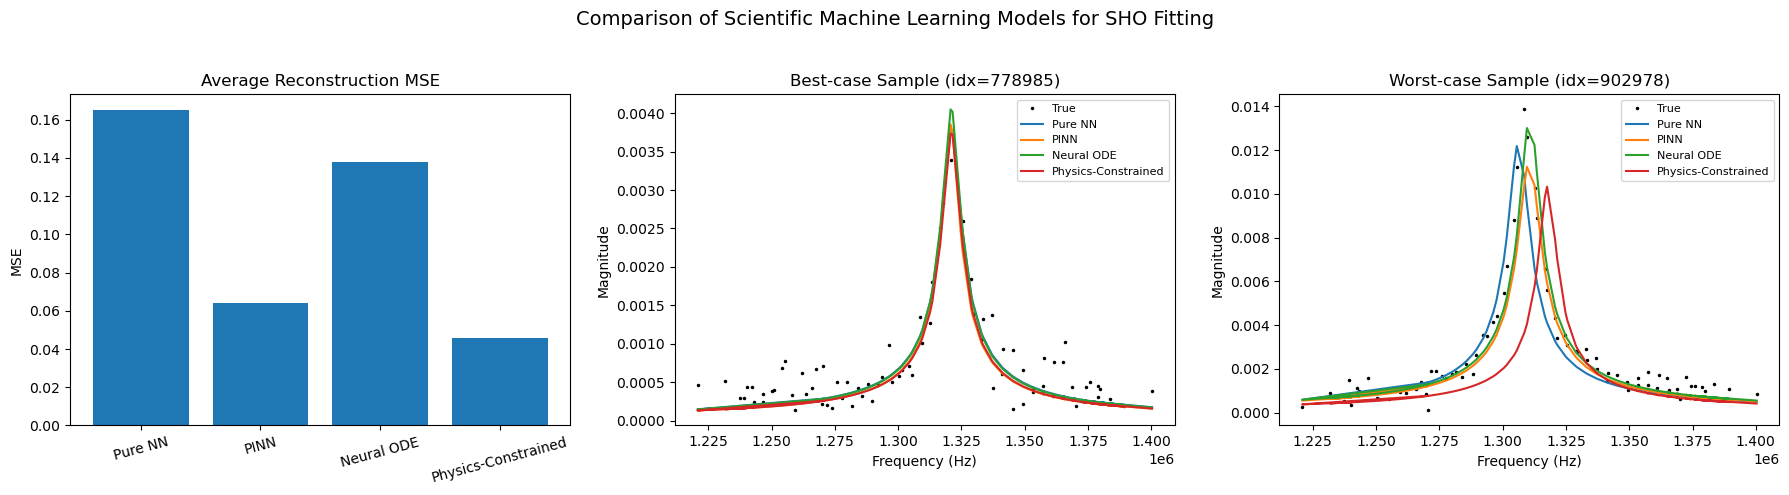

In [12]:
import numpy as np
import matplotlib.pyplot as plt

model_names = ["Pure NN", "PINN", "Neural ODE", "Physics-Constrained"]
recon_mse = [pure_avg_mse, pinn_avg_mse, node_avg_mse, avg_mse]

# parameter MSE arrays should be [Amp, w0, Q, phi]
param_labels = ["Amp", "Freq", "Q", "Phase"]
param_mse_matrix = np.array([
    pure_param_mse,
    pinn_param_mse,
    node_param_mse,
    param_mse
], dtype=float)

# Use best/worst from physics-constrained model as the common examples
best_sample = int(best_idx[0])
worst_sample = int(worst_idx[0])

# Ground truth from physics-constrained test set
x_true_best = X_test_complex[best_sample]
x_true_worst = X_test_complex[worst_sample]

# Predicted spectra for same sample index from each model
# Since all models used the same train/test split, these indices should align
pred_best = {
    "Pure NN": pure_pred_complex[best_sample],
    "PINN": pinn_pred_complex[best_sample],
    "Neural ODE": node_pred_complex[best_sample],
    "Physics-Constrained": pred_complex[best_sample],
}
pred_worst = {
    "Pure NN": pure_pred_complex[worst_sample],
    "PINN": pinn_pred_complex[worst_sample],
    "Neural ODE": node_pred_complex[worst_sample],
    "Physics-Constrained": pred_complex[worst_sample],
}

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Reconstruction MSE
axs[0].bar(model_names, recon_mse)
axs[0].set_title("Average Reconstruction MSE")
axs[0].set_ylabel("MSE")
axs[0].tick_params(axis='x', rotation=15)

# Best-case reconstruction 
axs[1].plot(wvec_freq, np.abs(x_true_best), "k.", markersize=3, label="True")
for name in model_names:
    axs[1].plot(wvec_freq, np.abs(pred_best[name]), label=name)
axs[1].set_title(f"Best-case Sample (idx={best_sample})")
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Magnitude")
axs[1].legend(fontsize=8)

# Worst-case reconstruction 
axs[2].plot(wvec_freq, np.abs(x_true_worst), "k.", markersize=3, label="True")
for name in model_names:
    axs[2].plot(wvec_freq, np.abs(pred_worst[name]), label=name)
axs[2].set_title(f"Worst-case Sample (idx={worst_sample})")
axs[2].set_xlabel("Frequency (Hz)")
axs[2].set_ylabel("Magnitude")
axs[2].legend(fontsize=8)

fig.suptitle("Comparison of Scientific Machine Learning Models for SHO Fitting", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("model_comparison_summary.png", dpi=300, bbox_inches="tight")
plt.show()

#### Citations

- Alibek Kaliyev, Ryan Forelli, et al. Rapid-Fitting-of-BEPFM-and-Hysteresis-Loops-Using-Physics-Constrained-Unsupervised-Neural-Networks. GitHub repository. https://github.com/abekek/Rapid-Fitting-of-BEPFM-and-Hysteresis-Loops-Using-Physics-Constrained-Unsupervised-Neural-Networks